# State Space Models with `dynestyx` and `numpyro_forecast`

[`dynestyx`](https://github.com/BasisResearch/dynestyx) is a probabilistic programming library for dynamical systems built on NumPyro. Its central object is a `DynamicalModel` (an initial condition, a state evolution and an observation model), and its single primitive `dsx.sample` is interpreted by effect handlers: a `Filter` marginalizes the latent path with a filtering algorithm (Kalman, ensemble Kalman, extended and unscented Kalman, particle filters) and adds the marginal log likelihood to the NumPyro trace, and a `Simulator` rolls the model forward in time. `numpyro_forecast` is a forecasting workflow layer: a model is a plain function `(covariates, data=None)` built from model building blocks that register the `"obs"` and `"forecast"` sites, and the drivers ([`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html), [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html), the metrics) read those sites by name.

The two libraries compose at the trace level. In this notebook we write a `dynestyx` state space model **as a `numpyro_forecast` model** through one new model building block, `filtered_series`. While training, the block runs `dsx.sample` under a `Filter`, so NUTS and SVI see only the model parameters: the latent path is integrated out, exactly for linear-Gaussian models. While forecasting, it nests the same `Filter` inside a `Simulator`, which starts the rollout from the filtered state at the last observed step, and it returns the horizon draws that the model registers as the `"forecast"` site. Nothing else changes: `forecast`, `backtest` and the evaluation metrics work on the model as on any other.

We work through two examples. The first is the local level model, where the mapping is exact: we fit the same generative process twice, in the direct form of the package (every per-step innovation is a latent that the sampler explores) and in the marginalized form (a Kalman filter inside the model), and compare posteriors, sampler efficiency and forecasts. The second adds a seasonal regression through the covariates, fits it with SVI, and runs the expanding-window backtest of the package on the `dynestyx` model, which is the evaluation direction suggested in [dynestyx#264](https://github.com/BasisResearch/dynestyx/issues/264). The design behind the block, with the `dynestyx` facts it relies on and their evidence, is written up in [`DYNESTYX_INTEGRATION_DESIGN.md`](https://github.com/juanitorduz/numpyro_forecast/blob/main/DYNESTYX_INTEGRATION_DESIGN.md).

`dynestyx` is not a dependency of the package. Install it next to the package with `pip install "numpyro_forecast[dynestyx]"` (or `uv sync --extra all --extra dynestyx` in a checkout).

## Prepare notebook

In [1]:
import time
from dataclasses import dataclass
from functools import partial
from typing import Any

import arviz as az
import dynestyx as dsx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from dynestyx import DynamicalModel, Filter, Simulator
from dynestyx.inference.configs.filter import BaseFilterConfig
from dynestyx.inference.configs.simulator import SimulatorConfig
from dynestyx.inference.filters import KFConfig
from jax import random
from jaxtyping import Float
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    forecast,
    innovations,
    predict,
    predictions_to_datatree,
    results_to_dataframe,
)
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

print(f"dynestyx {dsx.__version__}, numpyro {numpyro.__version__}, jax {jax.__version__}")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

dynestyx 0.5.0, numpyro 0.21.0, jax 0.11.0


## The building block

The block below is the whole integration. It takes the current call's [`Horizon`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html), a site name, a `dynestyx` `DynamicalModel` and a filter configuration, and it does one of two things depending on the horizon:

- **Training** (`h.future == 0`): run `dsx.sample` under `Filter`. The filter computes the marginal log likelihood $\log p(y_{1:T} \mid \theta)$ of the observed window and registers it as a NumPyro factor, so the joint density that NUTS or SVI sees is $p(\theta) \, p(y_{1:T} \mid \theta)$ with the latent path integrated out. The filter also records the filtered means and covariances as deterministic sites.
- **Forecasting** (`h.future > 0`): nest the same `Filter` inside a `Simulator`. `dynestyx` interprets this composition as a posterior rollout: the simulator starts each prediction segment from the filtered distribution at the last observed time that precedes it. The block returns the horizon draws (observations and states) so that the model can register them as `"forecast"`.

Two details are load-bearing. First, the time grids are NumPy arrays built from the horizon's Python integers, not `jnp.arange` calls: the package's `forecast` driver runs the model under `jax.jit`, and the simulator does its segment bookkeeping on the host, which only works when the times are constants. Second, the prediction grid starts at the last observed step, `t_obs - 1`, and the first returned row is dropped. The simulator's first predicted state is the initial-condition draw at `predict_times[0]` without a transition, and in a posterior rollout that draw comes from the filtered distribution at the last observation time not after `predict_times[0]`; anchoring at `t_obs - 1` therefore yields the filtered state there, followed by exactly one transition per horizon step. Without the anchor, the forecast for step `t_obs` would silently be the filtered state of step `t_obs - 1`.

Like [`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html), the block registers nothing of its own beyond the `dynestyx` sites; the caller writes `numpyro.deterministic("forecast", ...)` when forecasting. A marginalized model has no latent path to sample without observations, so the block refuses `data=None`: prior predictive checks go through `dsx.simulate` (shown below), and the package's `predict_in_sample` and `to_datatree` drivers, which call the model with `data=None`, do not apply to this class of model.

In [2]:
@dataclass(frozen=True)
class FilteredSeriesResult:
    """Horizon draws produced by `filtered_series` (size-0 time axes while training).

    Attributes
    ----------
    y_future
        Observation draws over the horizon, shape ``(future, obs)``.
    x_future
        Latent state draws over the horizon, shape ``(future, state)``.
    """

    y_future: Float[Array, " future obs"]
    x_future: Float[Array, " future state"]


def _time_grid(size: int, dt: float) -> np.ndarray:
    """Host-side float time grid ``[0, dt, ..., (size - 1) dt]`` (a constant under jit)."""
    return (np.arange(size) * dt).astype(np.float32)


def filtered_series(
    h: Horizon,
    name: str,
    dynamics: DynamicalModel,
    *,
    filter_config: BaseFilterConfig | None = None,
    controls: Float[Array, " duration control"] | None = None,
    dt: float = 1.0,
    simulator_config: SimulatorConfig | None = None,
) -> FilteredSeriesResult:
    """Condition a dynestyx model on the observed window and roll it over the horizon.

    In-sample the block runs ``dsx.sample`` under ``Filter``, which adds the
    marginal log likelihood of the observed window as a NumPyro factor; when
    forecasting it nests the same ``Filter`` inside a ``Simulator`` whose
    posterior rollout starts from the filtered state at the last observed step
    and returns the horizon draws. The guide never sees the rollout because
    fitting always happens with ``h.future == 0``.

    Parameters
    ----------
    h
        The horizon for the current model call; ``h.data`` must be present.
    name
        Prefix of the ``dynestyx`` sites (``{name}_marginal_loglik``,
        ``{name}_filtered_states_mean``, ``{name}_predicted_observations``, ...).
    dynamics
        The ``dynestyx`` model; its observation dimension must match ``h.data``.
    filter_config
        The filter to condition with (``KFConfig()`` for linear-Gaussian
        models). ``None`` takes the ``dynestyx`` default, an ensemble Kalman
        filter, which is approximate.
    controls
        Exogenous inputs over the full horizon, shape ``(duration, control)``,
        normally the model's ``covariates``; forwarded as ``ctrl_values`` on a
        grid covering the observation and prediction times.
    dt
        Spacing that maps integer steps to ``dynestyx`` float times.
    simulator_config
        Forwarded to ``Simulator`` (solver options for continuous-time models).

    Returns
    -------
    FilteredSeriesResult
        The horizon draws ``y_future`` and ``x_future``.

    Raises
    ------
    ValueError
        If ``h.data`` is ``None``.
    """
    if h.data is None:
        msg = (
            "filtered_series needs observed data: a marginalized model has no latent "
            "path to sample without observations. Prior predictive checks go through "
            "dynestyx.simulate; predict_in_sample and to_datatree are not applicable."
        )
        raise ValueError(msg)
    # The grids are NumPy constants on purpose (see the text above); dynestyx annotates
    # them as jax Arrays but accepts array-likes, hence the untyped keyword dict.
    grids: dict[str, Any] = {"obs_times": _time_grid(h.t_obs, dt)}
    if controls is not None:
        grids |= {"ctrl_times": _time_grid(h.duration, dt), "ctrl_values": controls}
    if h.future == 0:
        with Filter(filter_config=filter_config):
            dsx.sample(name, dynamics, obs_values=h.data, **grids)
        return FilteredSeriesResult(
            y_future=jnp.zeros((0, dynamics.observation_dim)),
            x_future=jnp.zeros((0, dynamics.state_dim)),
        )
    # Anchor the rollout at the last observed step (see the text above).
    grids["predict_times"] = _time_grid(h.duration, dt)[h.t_obs - 1 :]
    simulator = Simulator(simulator_config, n_simulations=1)
    with numpyro.handlers.trace() as tr, simulator, Filter(filter_config=filter_config):
        dsx.sample(name, dynamics, obs_values=h.data, **grids)
    y = tr[f"{name}_predicted_observations"]["value"]  # (n_sim, future + 1, obs)
    x = tr[f"{name}_predicted_states"]["value"]  # (n_sim, future + 1, state)
    return FilteredSeriesResult(y_future=y[0, 1:, :], x_future=x[0, 1:, :])

## Example 1: the local level model, two inference strategies

The local level model is the simplest structural time series model. The latent level $x_t$ is a random walk with state noise scale $q$, and the observation $y_t$ is the level plus noise with scale $r$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` this is `LTI_discrete` (linear time-invariant, discrete time) with transition matrix $A = 1$, state covariance $Q = q^2$, observation matrix $H = 1$ and observation covariance $R = r^2$. We write the dynamics as a small function of the two scales, so the same object serves the generative model, the prior predictive check and the inference model.

In [3]:
def local_level_dynamics(q: Array, r: Array) -> DynamicalModel:
    """Local level dynamics with state noise scale ``q`` and observation noise scale ``r``."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )

### Generate synthetic data

We simulate $144$ steps from the model with known scales $q = 0.3$ and $r = 0.5$ using `dsx.simulate`, the pure-JAX generator of `dynestyx` (it takes an explicit key and registers no NumPyro sites), and hold out the last $24$ steps as the test window. The package expects time at axis $-2$ and the observation dimension at axis $-1$, which is the layout `dsx.simulate` returns. There are no covariates in this example, so the covariate array has zero columns and only fixes the horizon.

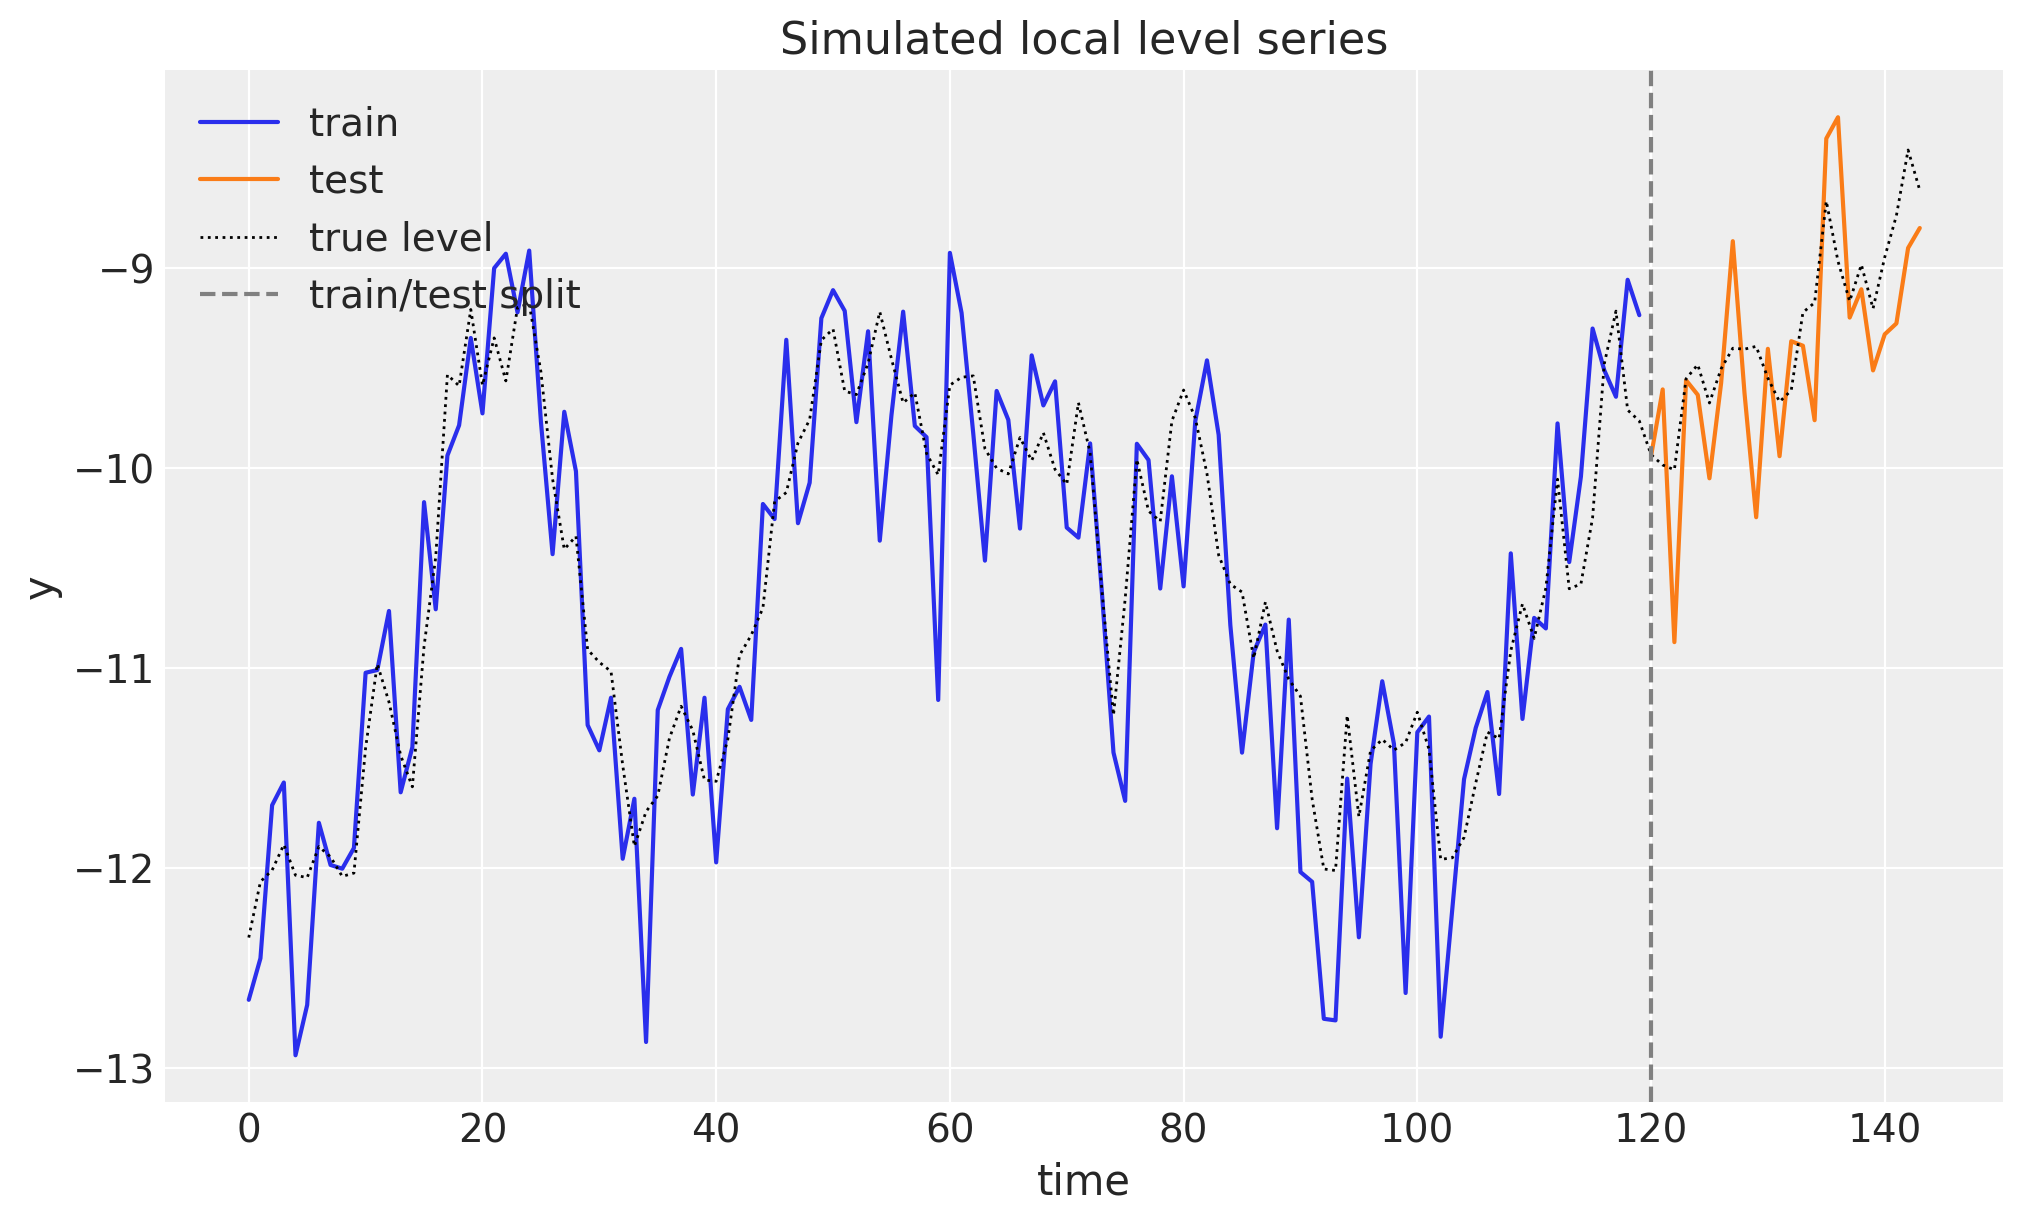

In [4]:
q_true, r_true = 0.3, 0.5
t_obs, future = 120, 24
duration = t_obs + future
time_index = np.arange(duration)

rng_key, rng_subkey = random.split(rng_key)
simulated = dsx.simulate(
    local_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true)),
    rng_key=rng_subkey,
    predict_times=jnp.asarray(_time_grid(duration, 1.0)),
)
assert simulated.observations is not None and simulated.states is not None  # raw simulation
y_full = simulated.observations[0]  # (duration, 1)
x_true = simulated.states[0, :, 0]  # (duration,)

train_data, test_data = y_full[:t_obs], y_full[t_obs:]
covariates_full = jnp.zeros((duration, 0))
covariates_train = covariates_full[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_data[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_data[:, 0], color="C1", label="test")
ax.plot(time_index, x_true, color="black", lw=1, ls=":", label="true level")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series", xlabel="time", ylabel="y");

### Prior predictive check

The priors on both scales are $\text{HalfNormal}(1)$, and the initial level is $\text{Normal}(0, 10)$. Before fitting anything we look at the series these priors generate. For a marginalized model the prior predictive is a forward simulation, so we write a tiny generative model in native `dynestyx` style (`dsx.sample` with `predict_times` only) and run it under a `Simulator` with NumPyro's `Predictive`. The prior paths cover the observed series comfortably without being absurdly wide.

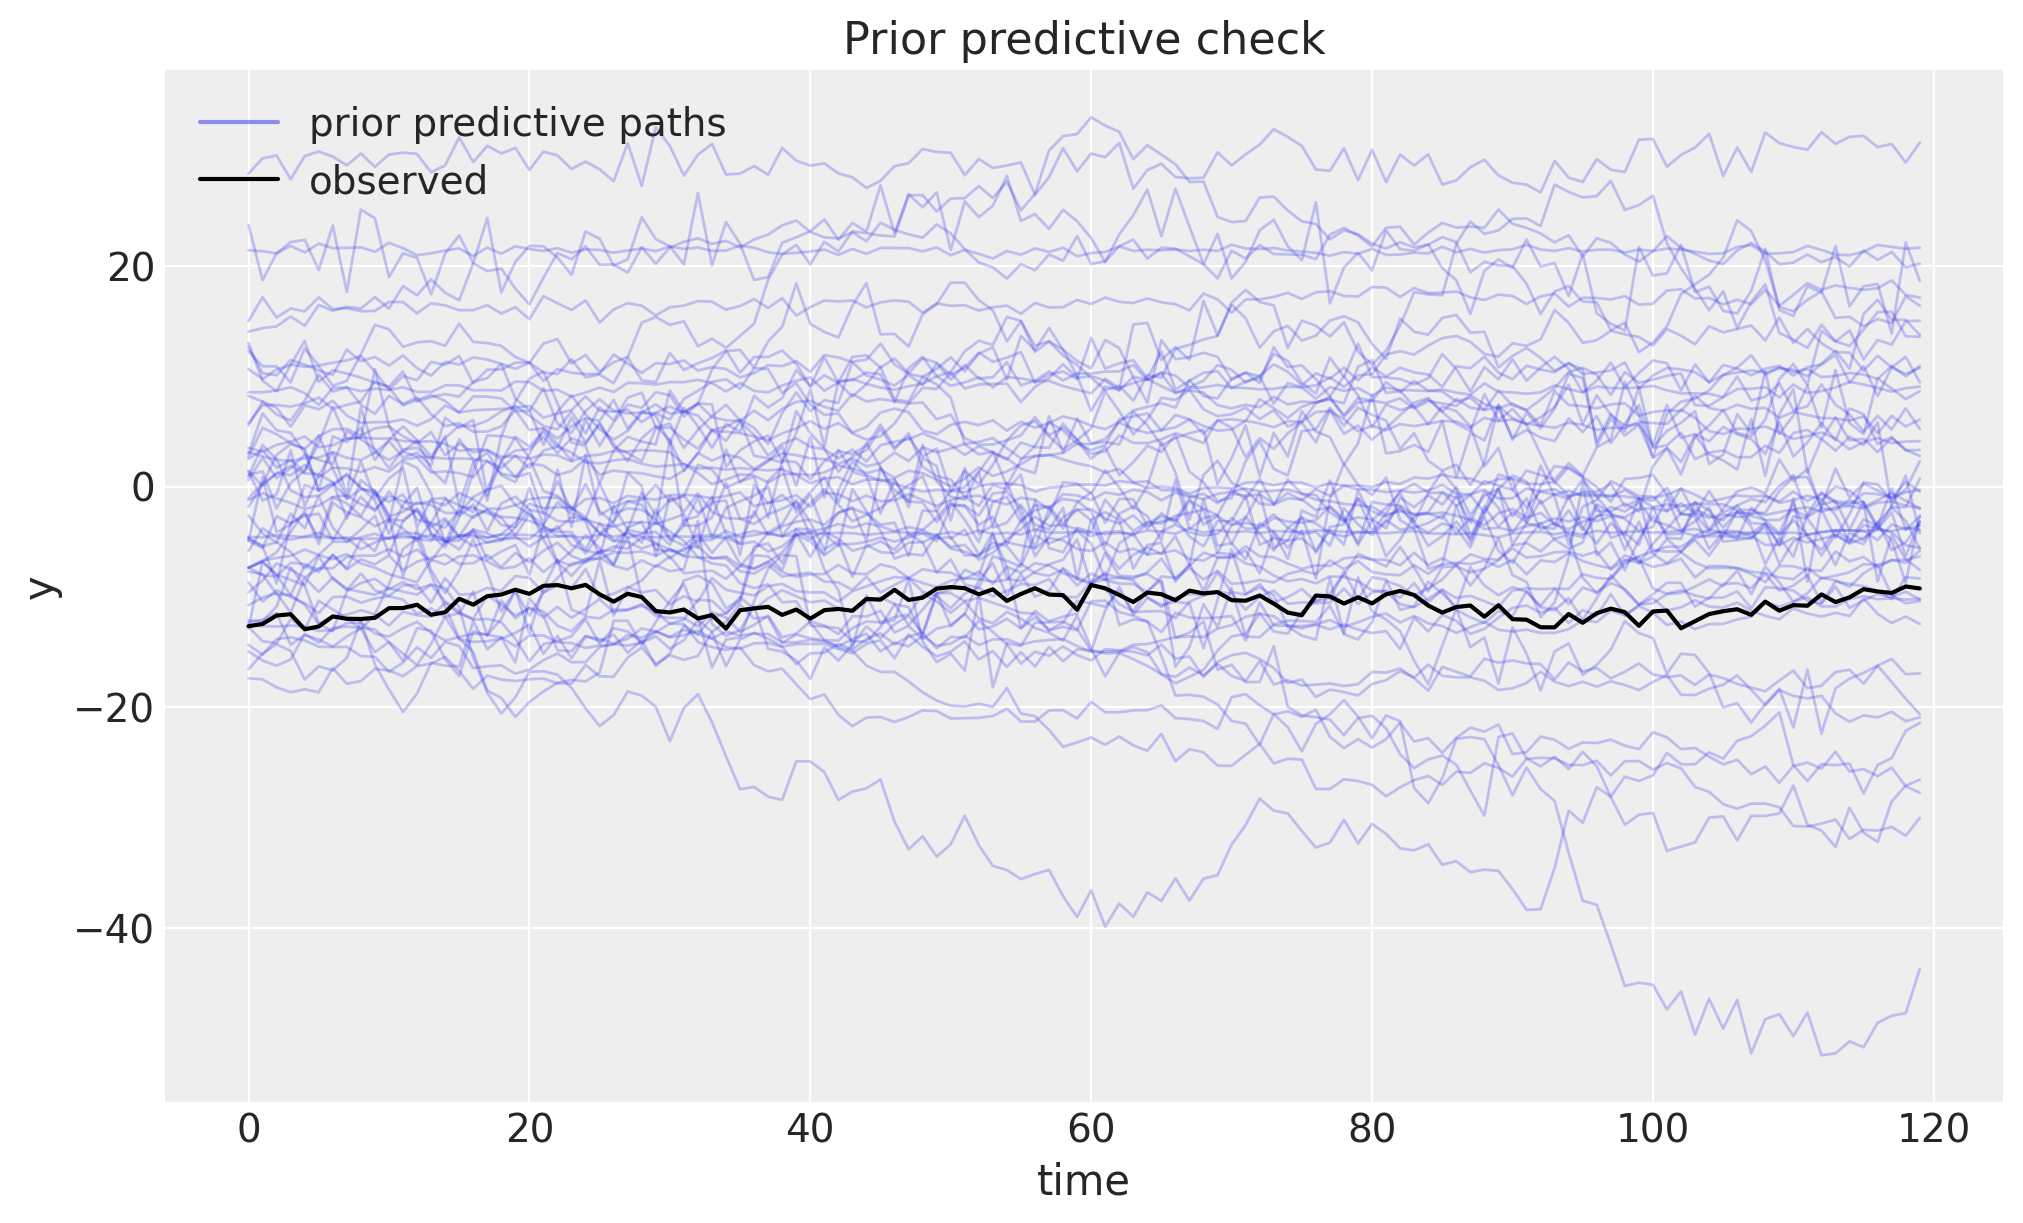

In [5]:
def local_level_prior(predict_times: Array) -> None:
    """Sample the scales from their priors and simulate a path from the local level model."""
    # jnp.asarray only narrows numpyro's union return type for the type checker.
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    dsx.sample("f", local_level_dynamics(q, r), predict_times=predict_times)


rng_key, rng_subkey = random.split(rng_key)
with Simulator(n_simulations=1):
    prior_draws = Predictive(local_level_prior, num_samples=50, exclude_deterministic=False)(
        rng_subkey, predict_times=jnp.asarray(_time_grid(t_obs, 1.0))
    )
prior_paths = np.asarray(prior_draws["f_observations"][:, 0, :, 0])  # (50, t_obs)

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], prior_paths.T, color="C0", alpha=0.25, lw=1)
ax.plot([], [], color="C0", alpha=0.5, label="prior predictive paths")
ax.plot(time_index[:t_obs], train_data[:, 0], color="black", lw=1.5, label="observed")
ax.legend(loc="upper left")
ax.set(title="Prior predictive check", xlabel="time", ylabel="y");

### The two models

Both models are plain NumPyro functions `(covariates, data=None)` with the same priors and the same generative process; they differ only in how the latent level enters the trace.

The **direct** model is the idiomatic `numpyro_forecast` form: [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html) samples one innovation per time step (with a `LocScaleReparam` to soften the funnel between $q$ and the path), the level is their cumulative sum plus the initial level, and [`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html) registers the likelihood. The sampler explores $t_{\text{obs}} + 3$ dimensions.

The **marginalized** model hands the dynamics to `filtered_series` with a Kalman filter configuration. The filter replaces the `t_{\text{obs}}` per-step latents by their exact integral, so the sampler explores $2$ dimensions. `KFConfig()` selects the `cd_dynamax` backend, which is the cheapest for a short series on the CPU; `KFConfig(filter_source="cuthbert")` adds support for missing observations and time-varying parameters at a higher cost per gradient.

In [6]:
def local_level_direct(covariates: Array, data: Array | None = None) -> None:
    """Local level model with the innovations sampled explicitly."""
    h = Horizon.from_data(covariates, data)
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    x0 = jnp.asarray(numpyro.sample("x0", dist.Normal(0.0, 10.0)))
    drift = innovations(h, "drift", lambda: dist.Normal(0.0, q), reparam=LocScaleReparam(0))
    level = x0 + jnp.cumsum(drift, axis=-2)
    predict(h, dist.Normal(0.0, r), level)


def local_level_filtered(covariates: Array, data: Array | None = None) -> None:
    """Local level model with the level marginalized by a Kalman filter."""
    h = Horizon.from_data(covariates, data)
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    result = filtered_series(h, "f", local_level_dynamics(q, r), filter_config=KFConfig())
    if h.future > 0:
        numpyro.deterministic("forecast", result.y_future)

### Fit both with NUTS

We run the same sampler budget on both models: $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps. The `num_steps` extra field records the number of leapfrog steps, that is, gradient evaluations, which is what NUTS spends its time on. `mcmc.get_samples()` returns the flattened posterior dictionary that the package drivers consume; for the marginalized model it also carries the deterministic sites recorded by the filter (`f_marginal_loglik`, `f_filtered_states_mean`, `f_filtered_states_cov`, ...).

In [7]:
def fit_nuts(
    rng_key: Array,
    model: ForecastModel,
    data: Array,
    covariates: Array,
    *,
    num_chains: int = 4,
    num_warmup: int = 1_000,
    num_samples: int = 1_000,
) -> tuple[MCMC, float]:
    """Fit ``model`` with NUTS and return the sampler and the wall time in seconds."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        chain_method="sequential",
        progress_bar=False,
    )
    start = time.perf_counter()
    mcmc.run(rng_key, covariates, data, extra_fields=("num_steps",))
    jax.block_until_ready(mcmc.get_samples())
    return mcmc, time.perf_counter() - start


rng_key, rng_subkey = random.split(rng_key)
mcmc_direct, wall_direct = fit_nuts(rng_subkey, local_level_direct, train_data, covariates_train)
posterior_direct = mcmc_direct.get_samples()

rng_key, rng_subkey = random.split(rng_key)
mcmc_filtered, wall_filtered = fit_nuts(
    rng_subkey, local_level_filtered, train_data, covariates_train
)
posterior_filtered = mcmc_filtered.get_samples()

print(f"direct model:       {wall_direct:6.1f} s, sites {sorted(posterior_direct)}")
print(f"marginalized model: {wall_filtered:6.1f} s, sites {sorted(posterior_filtered)}")

direct model:         13.4 s, sites ['drift', 'drift_decentered', 'q', 'r', 'x0']
marginalized model:   10.5 s, sites ['f_filtered_states_cov', 'f_filtered_states_cov_diag', 'f_filtered_states_mean', 'f_marginal_loglik', 'q', 'r']


### Compare the fits

The posteriors of the two scales agree with each other, as they must: the two models define the same joint distribution over $(q, r, y_{1:T})$, and the filter integrates the level out exactly. Both place the true values inside their bulk (with $120$ observations the scales are only moderately well identified, so a posterior mean one standard deviation away from the truth is expected). What differs is the work the sampler had to do. We collect the effective sample sizes and $\hat{R}$ with ArviZ (the `(chain, draw)` layout comes from `get_samples(group_by_chain=True)`) next to the wall time and the number of gradient evaluations.

In [8]:
def summarize_fit(mcmc: MCMC, label: str, wall: float) -> pd.DataFrame:
    """One-row table of posterior means, diagnostics and sampler cost for ``q`` and ``r``."""
    grouped = mcmc.get_samples(group_by_chain=True)
    tree = az.from_dict({"posterior": {name: np.asarray(grouped[name]) for name in ("q", "r")}})
    summary = az.summary(tree, var_names=["q", "r"])
    num_steps = int(np.asarray(mcmc.get_extra_fields(group_by_chain=True)["num_steps"]).sum())
    return pd.DataFrame(
        {
            "q mean": [summary.loc["q", "mean"]],
            "q sd": [summary.loc["q", "sd"]],
            "r mean": [summary.loc["r", "mean"]],
            "r sd": [summary.loc["r", "sd"]],
            "ess_bulk q": [summary.loc["q", "ess_bulk"]],
            "ess_bulk r": [summary.loc["r", "ess_bulk"]],
            "r_hat q": [summary.loc["q", "r_hat"]],
            "r_hat r": [summary.loc["r", "r_hat"]],
            "leapfrog steps": [num_steps],
            "wall time (s)": [wall],
        },
        index=[label],
    )


comparison = pd.concat(
    [
        summarize_fit(mcmc_direct, "direct (innovations)", wall_direct),
        summarize_fit(mcmc_filtered, "marginalized (dynestyx KF)", wall_filtered),
    ]
)
print(f"truth: q = {q_true}, r = {r_true}")
comparison.round({"q mean": 3, "q sd": 3, "r mean": 3, "r sd": 3, "r_hat q": 3, "r_hat r": 3})

truth: q = 0.3, r = 0.5


,q mean,q sd,r mean,r sd,ess_bulk q,ess_bulk r,r_hat q,r_hat r,leapfrog steps,wall time (s)
direct (innovations),0.388,0.059,0.441,0.05,875.955108,798.614037,1.003,1.003,1019459,13.414731
marginalized (dynestyx KF),0.381,0.058,0.446,0.05,1657.219327,1717.445770,1.002,1.001,17592,10.532769


The marginalized sampler reaches a comparable or larger effective sample size with a small fraction of the gradient evaluations, because it moves in a two-dimensional posterior instead of a $123$-dimensional one whose geometry couples $q$ to every innovation. Each of its gradients is more expensive (a Kalman filter pass over the window instead of a sum of Gaussian log densities), so on a short series on the CPU the wall times end up in the same range; the advantage grows with the length of the series, since the direct posterior grows with it while the filter's cost is linear in it and leaves the sampler's geometry untouched, and on accelerators, where the parallel-in-time scan of the `cuthbert` backend pays off.

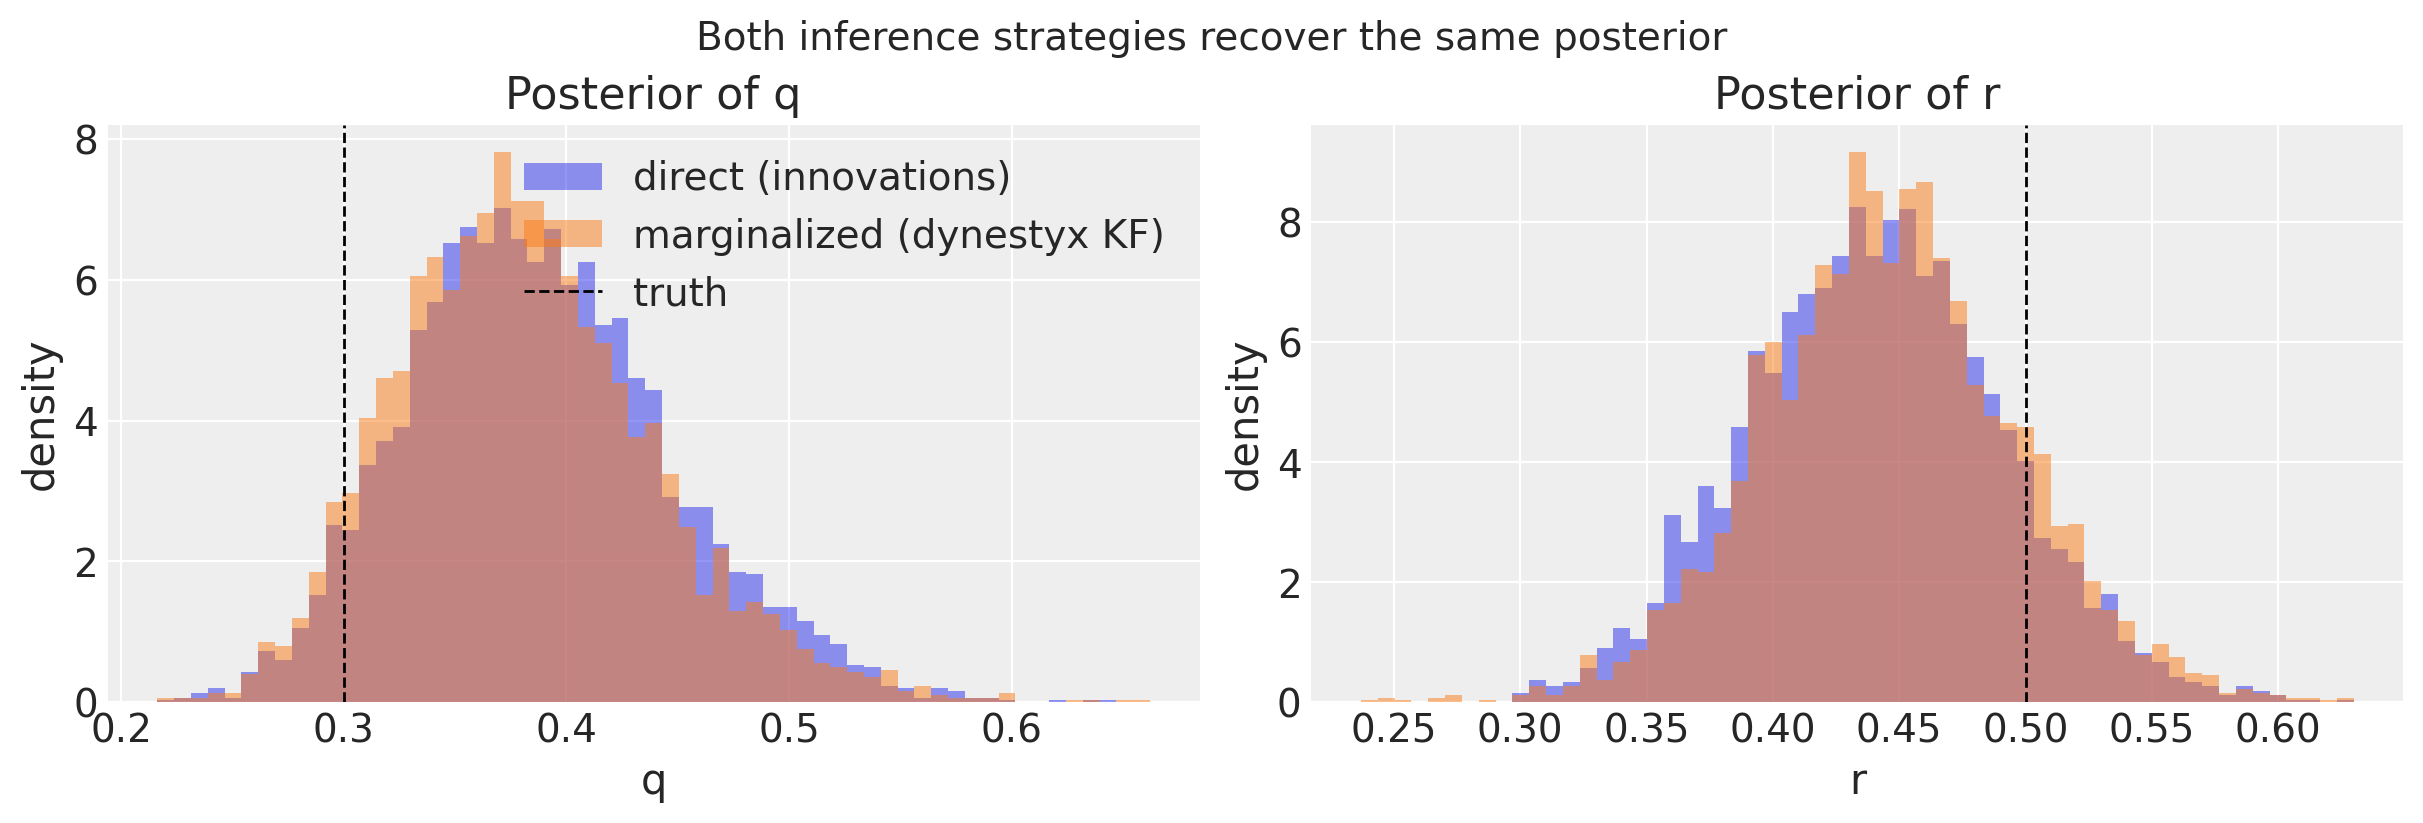

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
for ax, name, truth in zip(axes, ("q", "r"), (q_true, r_true), strict=True):
    bins = np.linspace(
        min(float(posterior_direct[name].min()), float(posterior_filtered[name].min())),
        max(float(posterior_direct[name].max()), float(posterior_filtered[name].max())),
        60,
    )
    ax.hist(
        np.asarray(posterior_direct[name]),
        bins=bins,
        density=True,
        alpha=0.5,
        color="C0",
        label="direct (innovations)",
    )
    ax.hist(
        np.asarray(posterior_filtered[name]),
        bins=bins,
        density=True,
        alpha=0.5,
        color="C1",
        label="marginalized (dynestyx KF)",
    )
    ax.axvline(truth, color="black", ls="--", lw=1, label="truth")
    ax.set(title=f"Posterior of {name}", xlabel=name, ylabel="density")
axes[0].legend(loc="upper right")
fig.suptitle("Both inference strategies recover the same posterior", fontsize=14);

### Forecast

Forecasting is the package's [`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html) driver in both cases: it runs `Predictive` over the full-horizon covariates and returns the `"forecast"` site with one path per posterior draw. For the direct model the in-sample innovations are replayed from the posterior and the future ones are drawn from the prior; for the marginalized model every draw re-runs the Kalman filter over the training window with its own $(q, r)$ and the simulator rolls the filtered state forward. The driver is jitted and vectorized over the draws, and the `dynestyx` handlers inside the model run under that `jit` and `vmap` without any special treatment.

In [10]:
def hdi_over_draws(draws: Array | np.ndarray, prob: float) -> tuple[np.ndarray, np.ndarray]:
    """Lower and upper HDI bounds over the sample axis of ``(sample, time, 1)`` draws."""
    bounds = az.hdi(np.moveaxis(np.asarray(draws)[..., 0], 0, -1), prob=prob)
    return bounds[..., 0], bounds[..., 1]


def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = {0.5: 0.6, 0.94: 0.3}  # 50% band darker, 94% band lighter

rng_key, key_direct, key_filtered = random.split(rng_key, 3)
forecast_direct = forecast(
    key_direct, local_level_direct, posterior_direct, train_data, covariates_full
)
forecast_filtered = forecast(
    key_filtered, local_level_filtered, posterior_filtered, train_data, covariates_full
)
print(f"forecast draws: direct {forecast_direct.shape}, marginalized {forecast_filtered.shape}")

forecast draws: direct (4000, 24, 1), marginalized (4000, 24, 1)


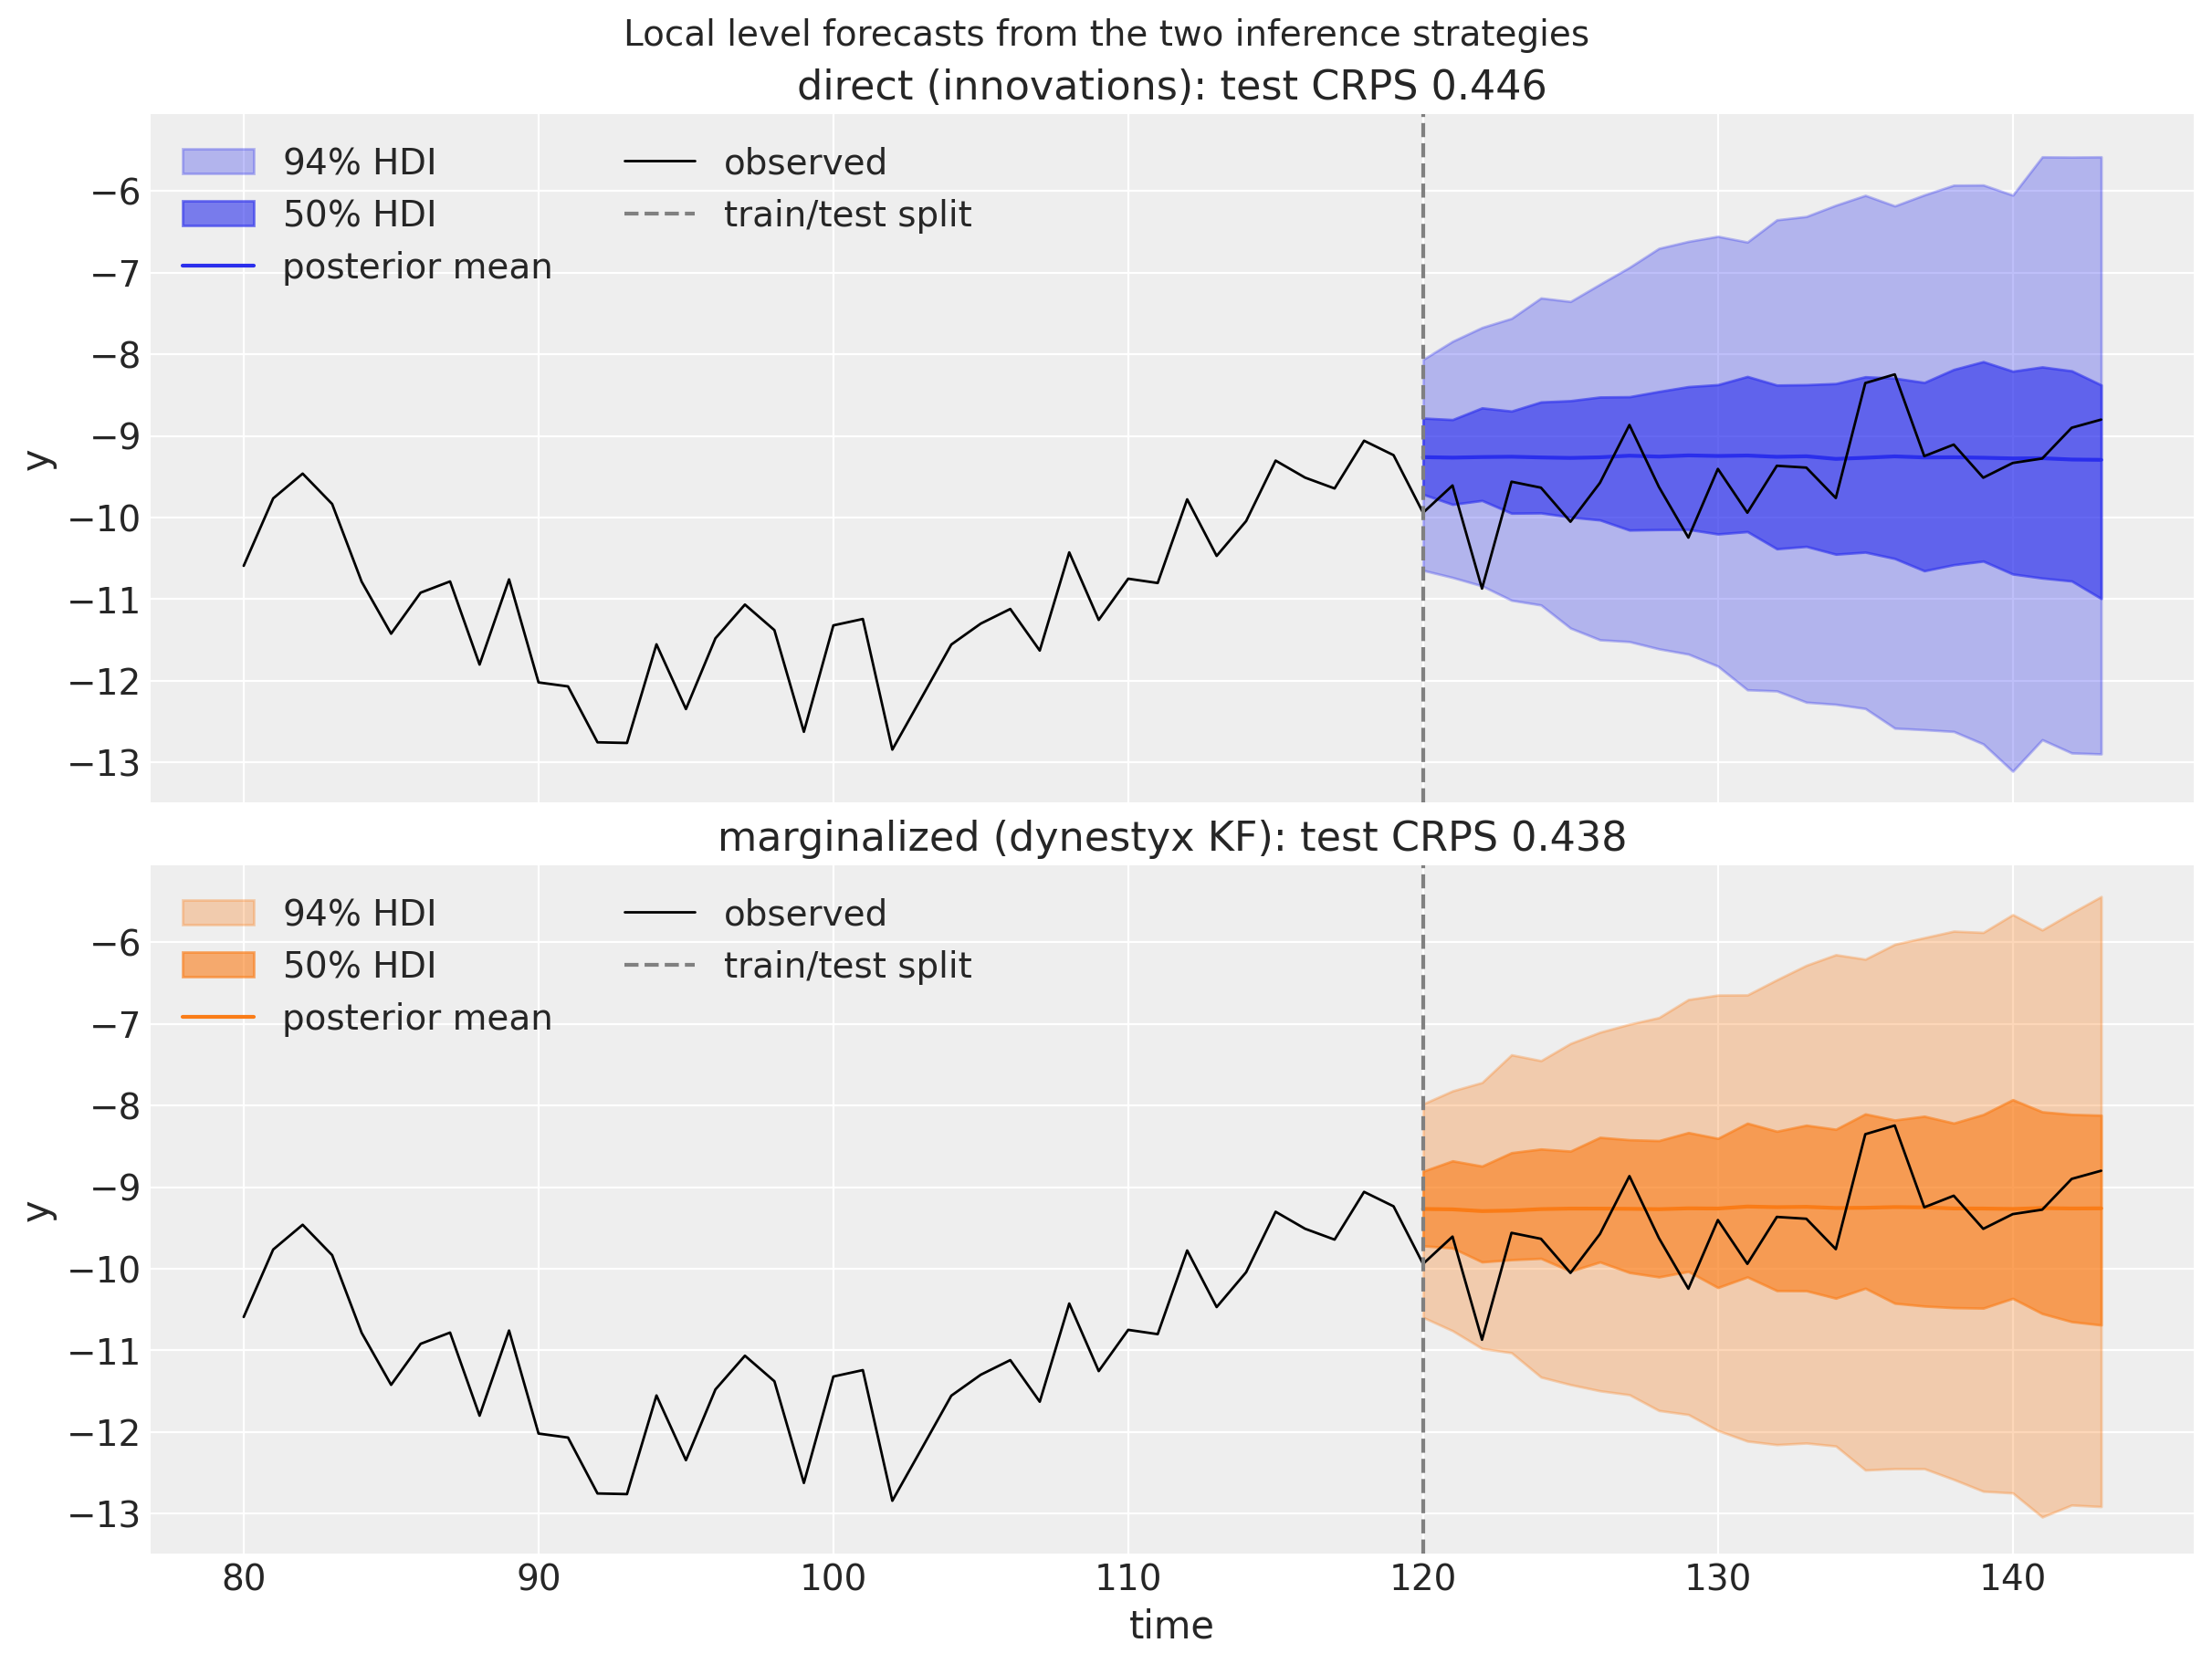

In [11]:
fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 9), sharex=True, sharey=True, layout="constrained"
)
future_index = time_index[t_obs:]
for ax, draws, color, label in zip(
    axes,
    (forecast_direct, forecast_filtered),
    ("C0", "C1"),
    ("direct (innovations)", "marginalized (dynestyx KF)"),
    strict=True,
):
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(draws, prob)
        ax.fill_between(
            future_index, lower, upper, color=color, alpha=hdi_alphas[prob], label=hdi_label(prob)
        )
    ax.plot(
        future_index, np.asarray(draws).mean(axis=0)[:, 0], color=color, label="posterior mean"
    )
    ax.plot(
        time_index[t_obs - 40 :], y_full[t_obs - 40 :, 0], color="black", lw=1, label="observed"
    )
    ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
    crps = eval_crps(draws, test_data)
    ax.set(title=f"{label}: test CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="upper left", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("Local level forecasts from the two inference strategies", fontsize=14);

The two fans are the same forecast up to Monte Carlo error, which is the point of the exercise: the marginalized model is not an approximation of the direct one, it is the same model with a better parameterization for the sampler. The metrics on the held-out window agree accordingly (point accuracy through MAE and RMSE, the CRPS as a proper score for the whole predictive distribution, and the empirical coverage of the central $50\%$ and $94\%$ intervals).

In [12]:
metric_fns = {
    "MAE": eval_mae,
    "RMSE": eval_rmse,
    "CRPS": eval_crps,
    "coverage (50%)": partial(eval_coverage, alpha=0.5),
    "coverage (94%)": partial(eval_coverage, alpha=0.94),
}
pd.DataFrame(
    {
        "direct (innovations)": {
            name: float(fn(forecast_direct, test_data)) for name, fn in metric_fns.items()
        },
        "marginalized (dynestyx KF)": {
            name: float(fn(forecast_filtered, test_data)) for name, fn in metric_fns.items()
        },
    }
).round(3)

,direct (innovations),marginalized (dynestyx KF)
MAE,0.463,0.454
RMSE,0.596,0.587
CRPS,0.446,0.438
coverage (50%),0.833,0.833
coverage (94%),0.958,1.000


### The filtered level

The marginalized model has no posterior over the level path, so the package's `predict_in_sample` does not apply to it; what the filter gives instead is the filtering distribution $p(x_t \mid y_{1:t}, \theta)$ at every step, whose mean and variance it recorded as the `f_filtered_states_mean` and `f_filtered_states_cov_diag` sites. Drawing one level per posterior draw from $\text{Normal}(m_{t \mid t}, \sqrt{P_{t \mid t}})$ mixes the two sources of uncertainty (the filter's and the parameters') into a single band. The direct model's posterior over `x0 + cumsum(drift)` is the *smoothed* level $p(x_t \mid y_{1:T}, \theta)$, which uses the whole window and is therefore tighter, in particular at the start of the series where the filter has seen little data. Both track the true level.

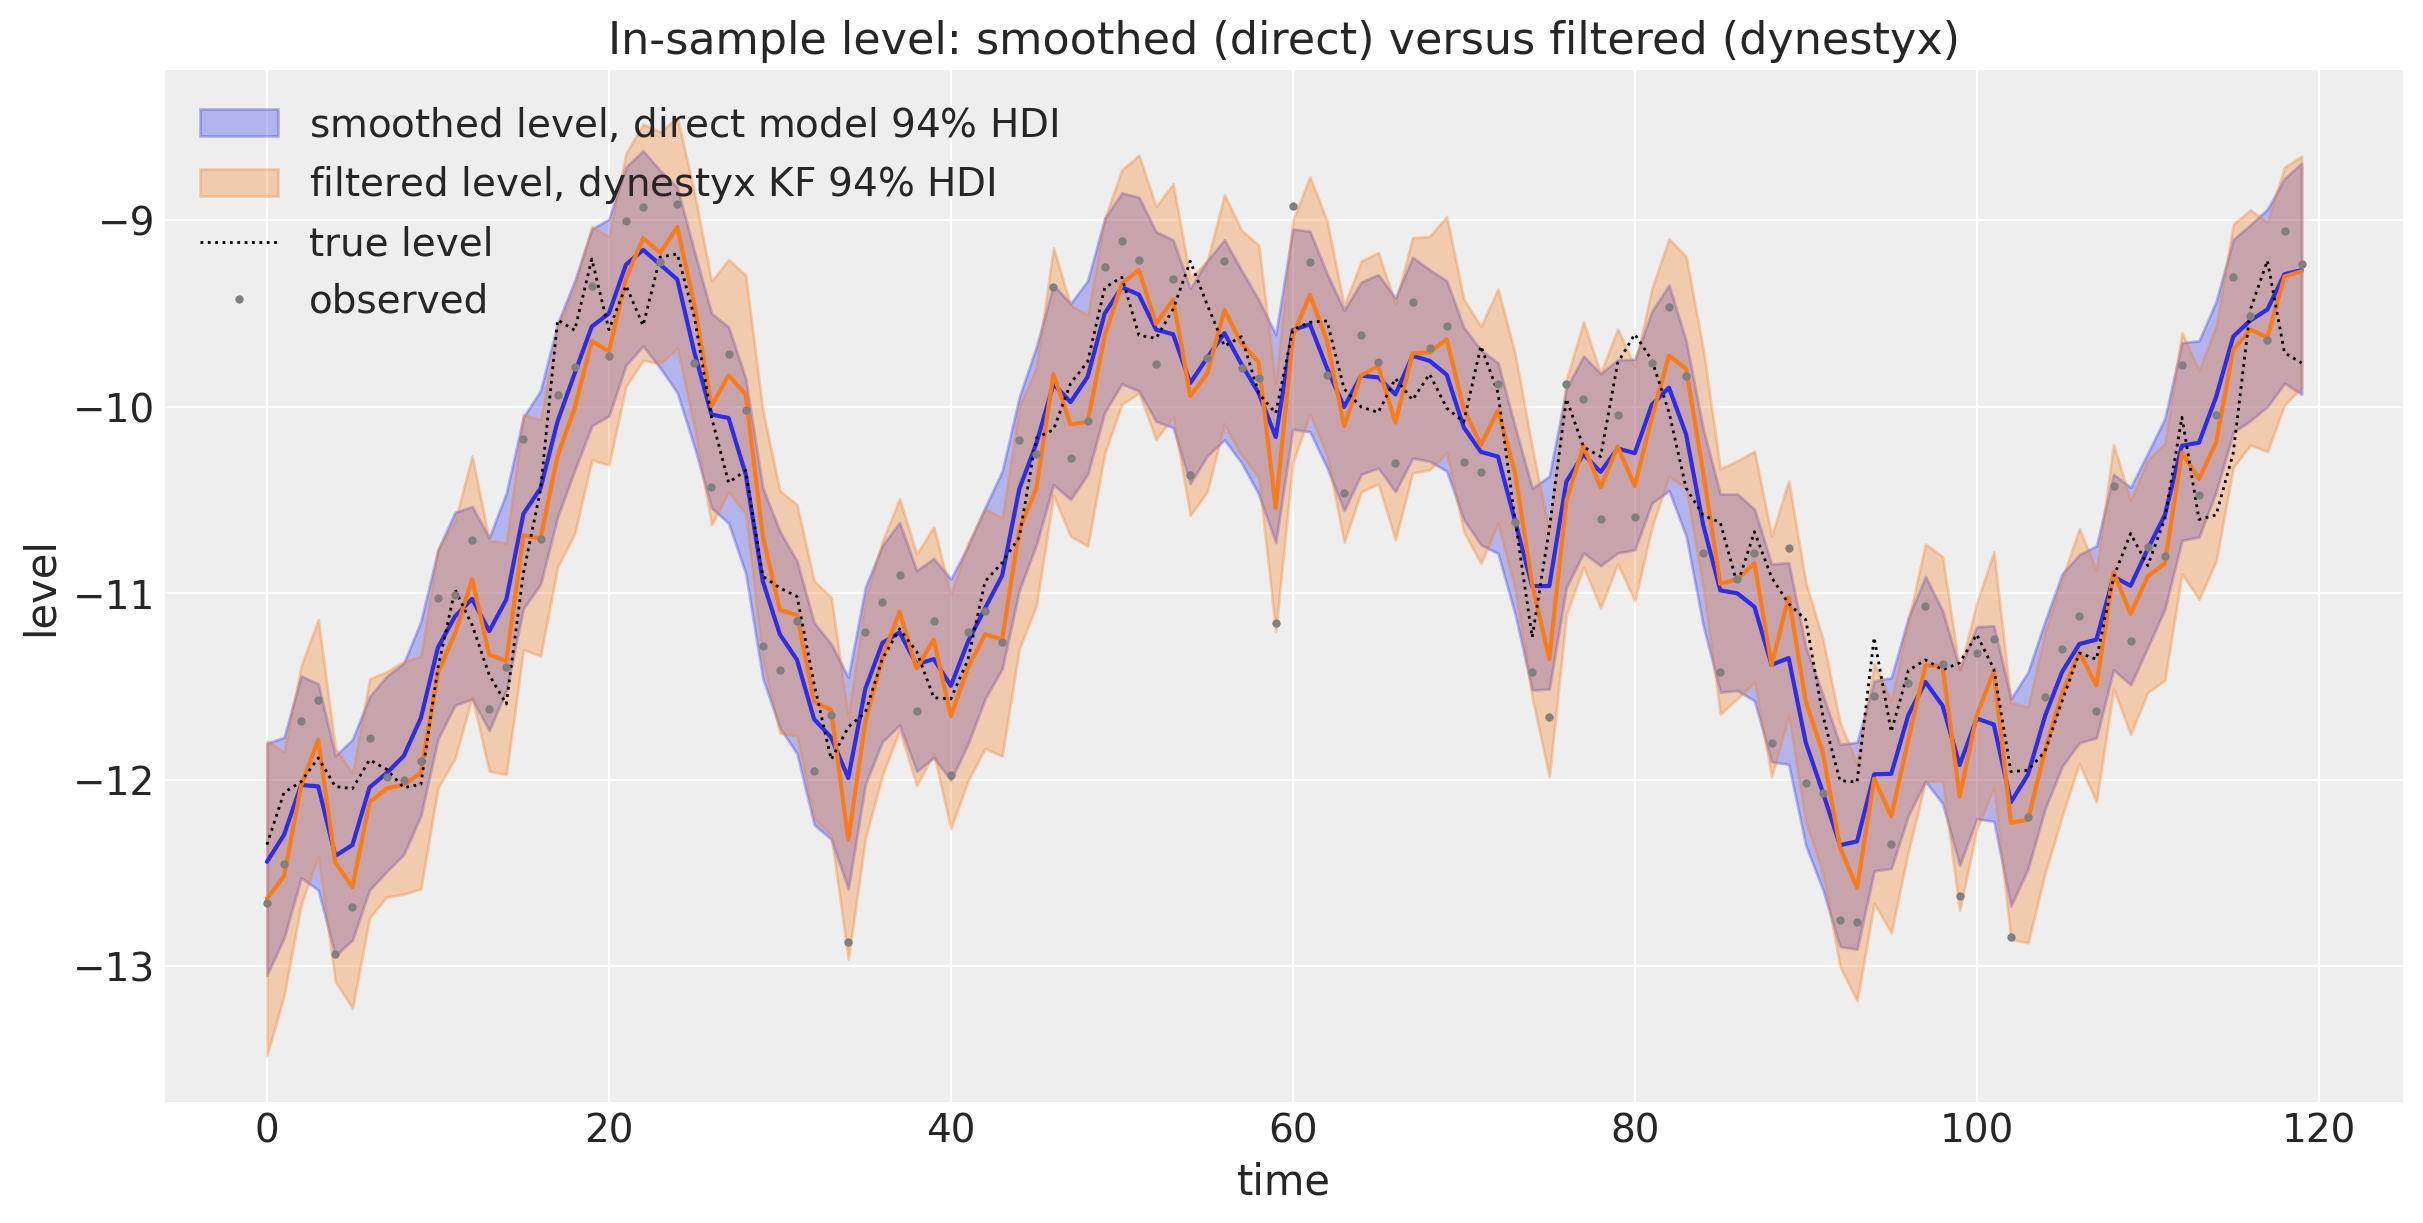

In [13]:
rng_key, rng_subkey = random.split(rng_key)
filtered_mean = np.asarray(posterior_filtered["f_filtered_states_mean"])  # (draws, t_obs, 1)
filtered_sd = np.sqrt(np.asarray(posterior_filtered["f_filtered_states_cov_diag"]))
filtered_level = filtered_mean + filtered_sd * np.asarray(
    random.normal(rng_subkey, filtered_mean.shape)
)
smoothed_level = np.asarray(
    posterior_direct["x0"][:, None, None] + jnp.cumsum(posterior_direct["drift"], axis=-2)
)

fig, ax = plt.subplots(figsize=(12, 6))
for draws, color, label in (
    (smoothed_level, "C0", "smoothed level, direct model"),
    (filtered_level, "C1", "filtered level, dynestyx KF"),
):
    lower, upper = hdi_over_draws(draws, 0.94)
    ax.fill_between(
        time_index[:t_obs],
        lower,
        upper,
        color=color,
        alpha=0.3,
        label=hdi_label(0.94, prefix=f"{label} "),
    )
    ax.plot(time_index[:t_obs], draws.mean(axis=0)[:, 0], color=color, lw=1.5)
ax.plot(time_index[:t_obs], x_true[:t_obs], color="black", lw=1, ls=":", label="true level")
ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="gray", ms=4, label="observed")
ax.legend(loc="upper left")
ax.set(
    title="In-sample level: smoothed (direct) versus filtered (dynestyx)",
    xlabel="time",
    ylabel="level",
);

## Example 2: seasonal regression through the covariates

The package routes everything a model needs at prediction time through the `covariates` array, which spans the full horizon. The block forwards that array to `dynestyx` as control inputs (`ctrl_values`) on a time grid that covers both the observed and the predicted steps, and the dynamics consume them wherever a control enters. Here a seasonal pattern enters the observation equation as a regression on Fourier features with coefficients $\beta$, so with $u_t$ the row of covariates at step $t$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + \beta^\top u_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` terms $\beta^\top u_t$ is the `D` matrix of a `LinearGaussianObservation`. One detail: `LTI_discrete` infers the control dimension from `B` alone, so a model whose controls enter only through `D` builds the `DynamicalModel` explicitly and passes `control_dim`.

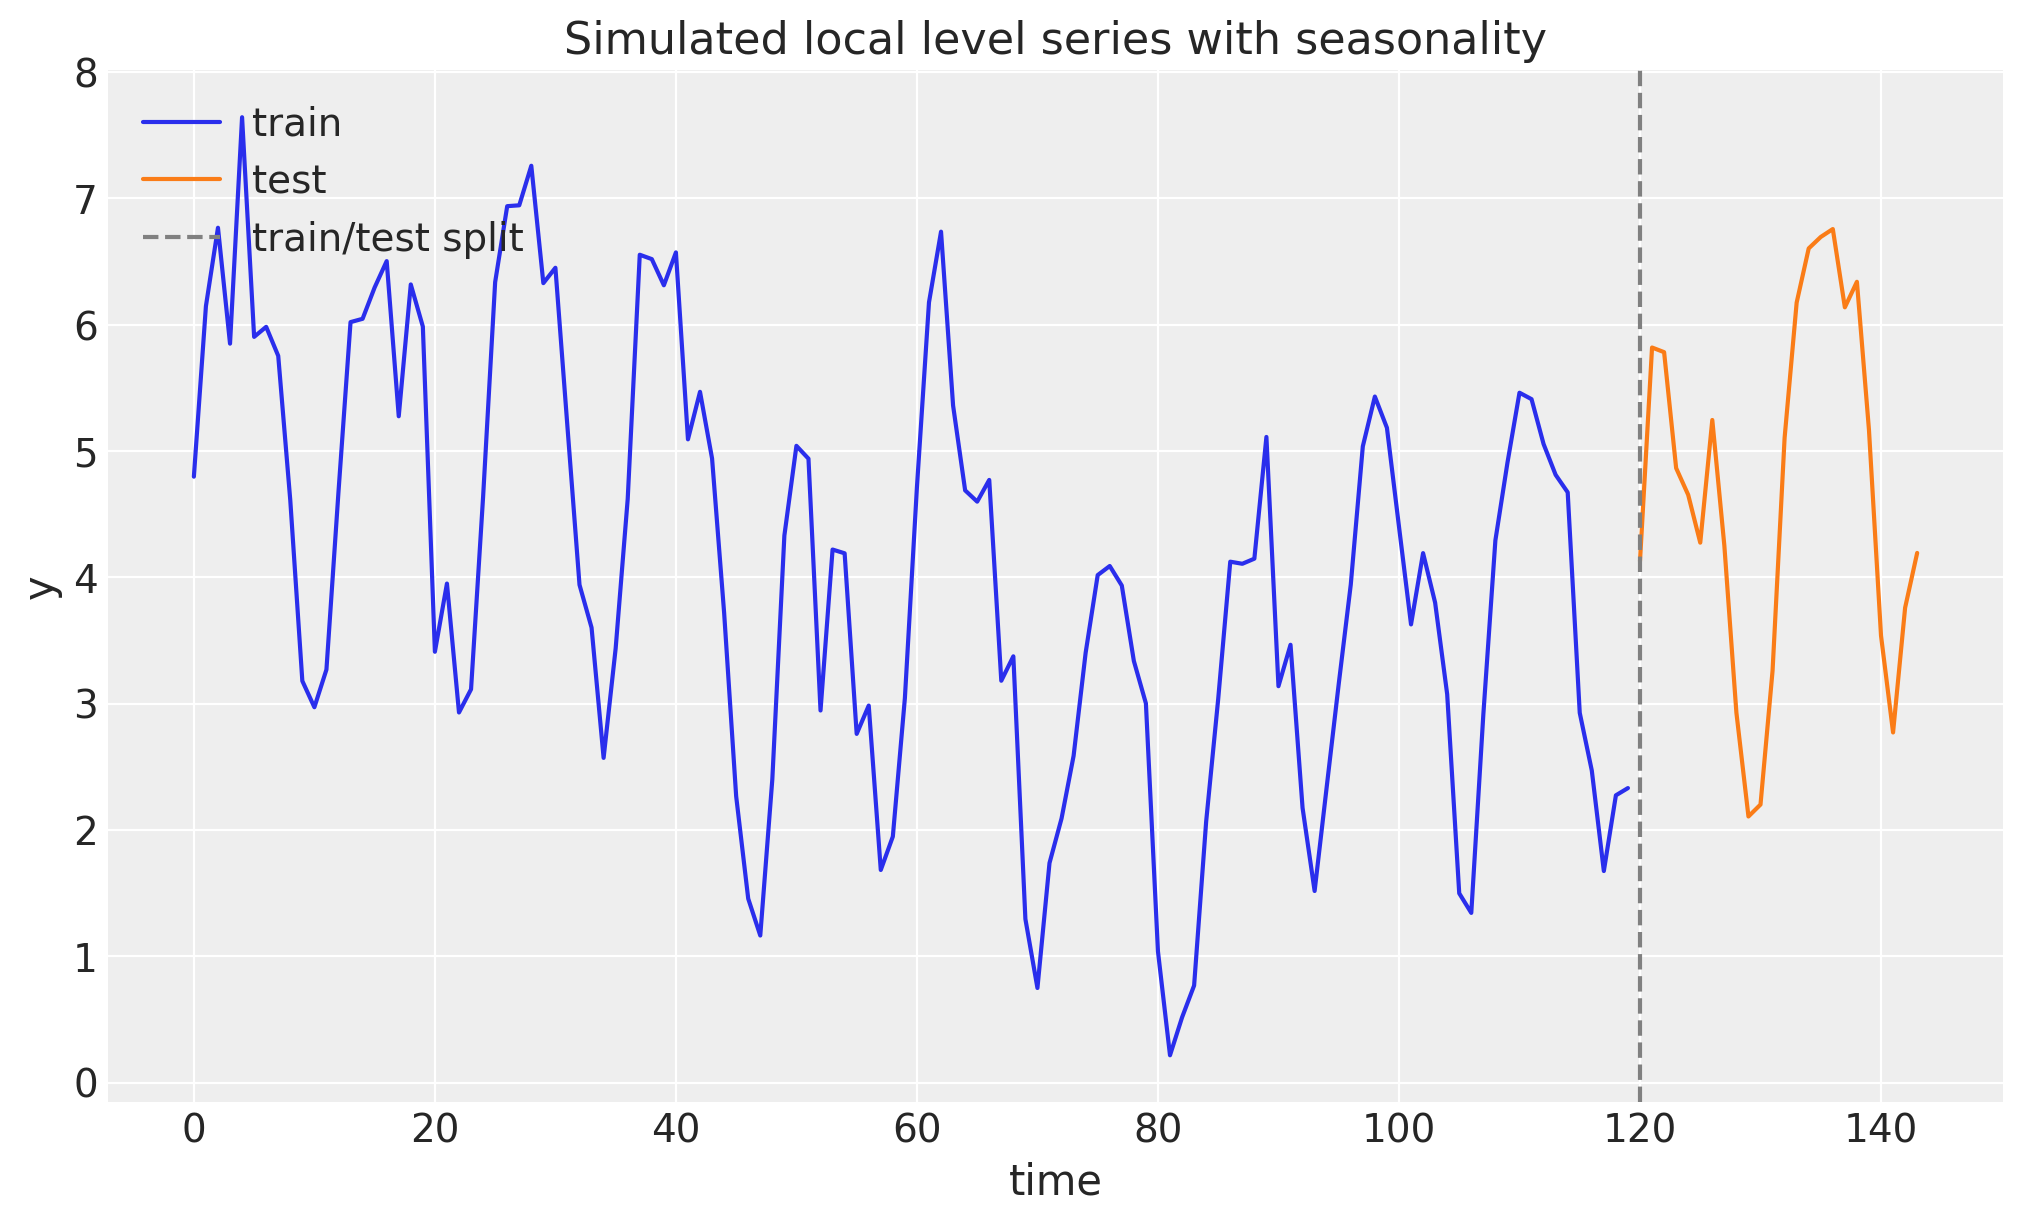

In [14]:
period, num_terms = 12.0, 2
beta_true = jnp.array([1.5, 0.5, -0.4, 0.3])
covariates_full = fourier_features(duration, period=period, num_terms=num_terms)  # (duration, 4)
covariates_train = covariates_full[:t_obs]


def seasonal_level_dynamics(q: Array, r: Array, beta: Array) -> DynamicalModel:
    """Local level dynamics with a regression on the controls in the observation equation."""
    return DynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(1), jnp.eye(1) * 100.0),
        state_evolution=dsx.LinearGaussianStateEvolution(A=jnp.eye(1), cov=jnp.eye(1) * q**2),
        observation_model=dsx.LinearGaussianObservation(
            H=jnp.eye(1), R=jnp.eye(1) * r**2, D=beta[None, :]
        ),
        control_dim=beta.shape[-1],
    )


rng_key, rng_subkey = random.split(rng_key)
simulated_seasonal = dsx.simulate(
    seasonal_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true), beta_true),
    rng_key=rng_subkey,
    ctrl_times=jnp.asarray(_time_grid(duration, 1.0)),
    ctrl_values=covariates_full,
    predict_times=jnp.asarray(_time_grid(duration, 1.0)),
)
assert simulated_seasonal.observations is not None  # raw simulation
y_seasonal = simulated_seasonal.observations[0]  # (duration, 1)
train_seasonal, test_seasonal = y_seasonal[:t_obs], y_seasonal[t_obs:]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_seasonal[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_seasonal[:, 0], color="C1", label="test")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series with seasonality", xlabel="time", ylabel="y");

The model adds a $\text{Normal}(0, 1)$ prior on the four coefficients and hands the covariates to the block as `controls`.

In [15]:
def seasonal_level_filtered(covariates: Array, data: Array | None = None) -> None:
    """Local level plus seasonal regression, level marginalized by a Kalman filter."""
    h = Horizon.from_data(covariates, data)
    num_features = covariates.shape[-1]
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    beta = jnp.asarray(
        numpyro.sample("beta", dist.Normal(0.0, 1.0).expand([num_features]).to_event(1))
    )
    result = filtered_series(
        h,
        "f",
        seasonal_level_dynamics(q, r, beta),
        filter_config=KFConfig(),
        controls=covariates,
    )
    if h.future > 0:
        numpyro.deterministic("forecast", result.y_future)

### Fit with SVI

Variational inference is the other standard path in the package and it works on the marginalized model unchanged: `AutoNormal` puts a mean-field Gaussian on the six unconstrained parameters and `Trace_ELBO` includes the filter's factor. Because the level is integrated out, the guide never has to approximate a $t_{\text{obs}}$-dimensional latent path, which is where mean-field guides usually underestimate uncertainty. We draw the posterior with [`draw_posterior`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.draw_posterior.html) and forecast as before.

SVI: 2.3 s, final loss 129.94
posterior mean of beta: [ 1.62  0.45 -0.41  0.26]
truth:                  [ 1.5  0.5 -0.4  0.3]


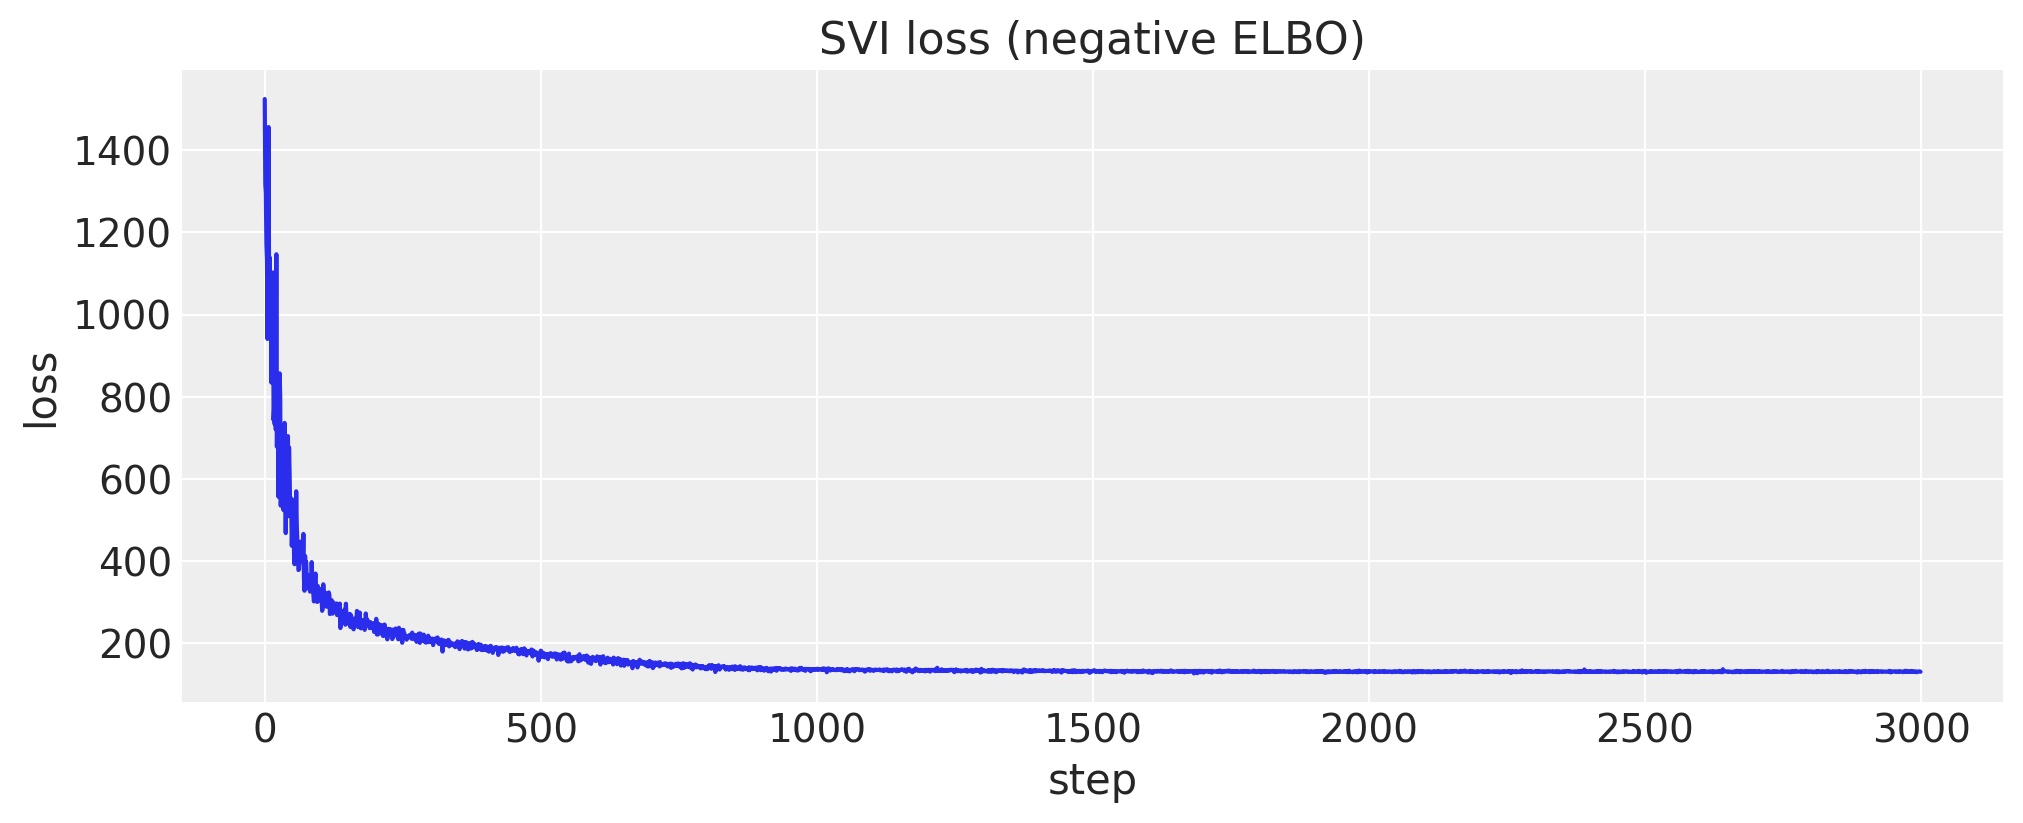

In [16]:
guide = AutoNormal(seasonal_level_filtered)
svi = SVI(seasonal_level_filtered, guide, Adam(step_size=0.01), Trace_ELBO())

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
svi_result = svi.run(rng_subkey, 3_000, covariates_train, train_seasonal, progress_bar=False)
wall_svi = time.perf_counter() - start

rng_key, key_post, key_pred = random.split(rng_key, 3)
posterior_svi = draw_posterior(key_post, guide, svi_result.params, num_samples=2_000)
forecast_svi = forecast(
    key_pred, seasonal_level_filtered, posterior_svi, train_seasonal, covariates_full
)
print(f"SVI: {wall_svi:.1f} s, final loss {float(svi_result.losses[-1]):.2f}")
print(f"posterior mean of beta: {np.asarray(posterior_svi['beta']).mean(axis=0).round(2)}")
print(f"truth:                  {np.asarray(beta_true)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.asarray(svi_result.losses), color="C0")
ax.set(title="SVI loss (negative ELBO)", xlabel="step", ylabel="loss");

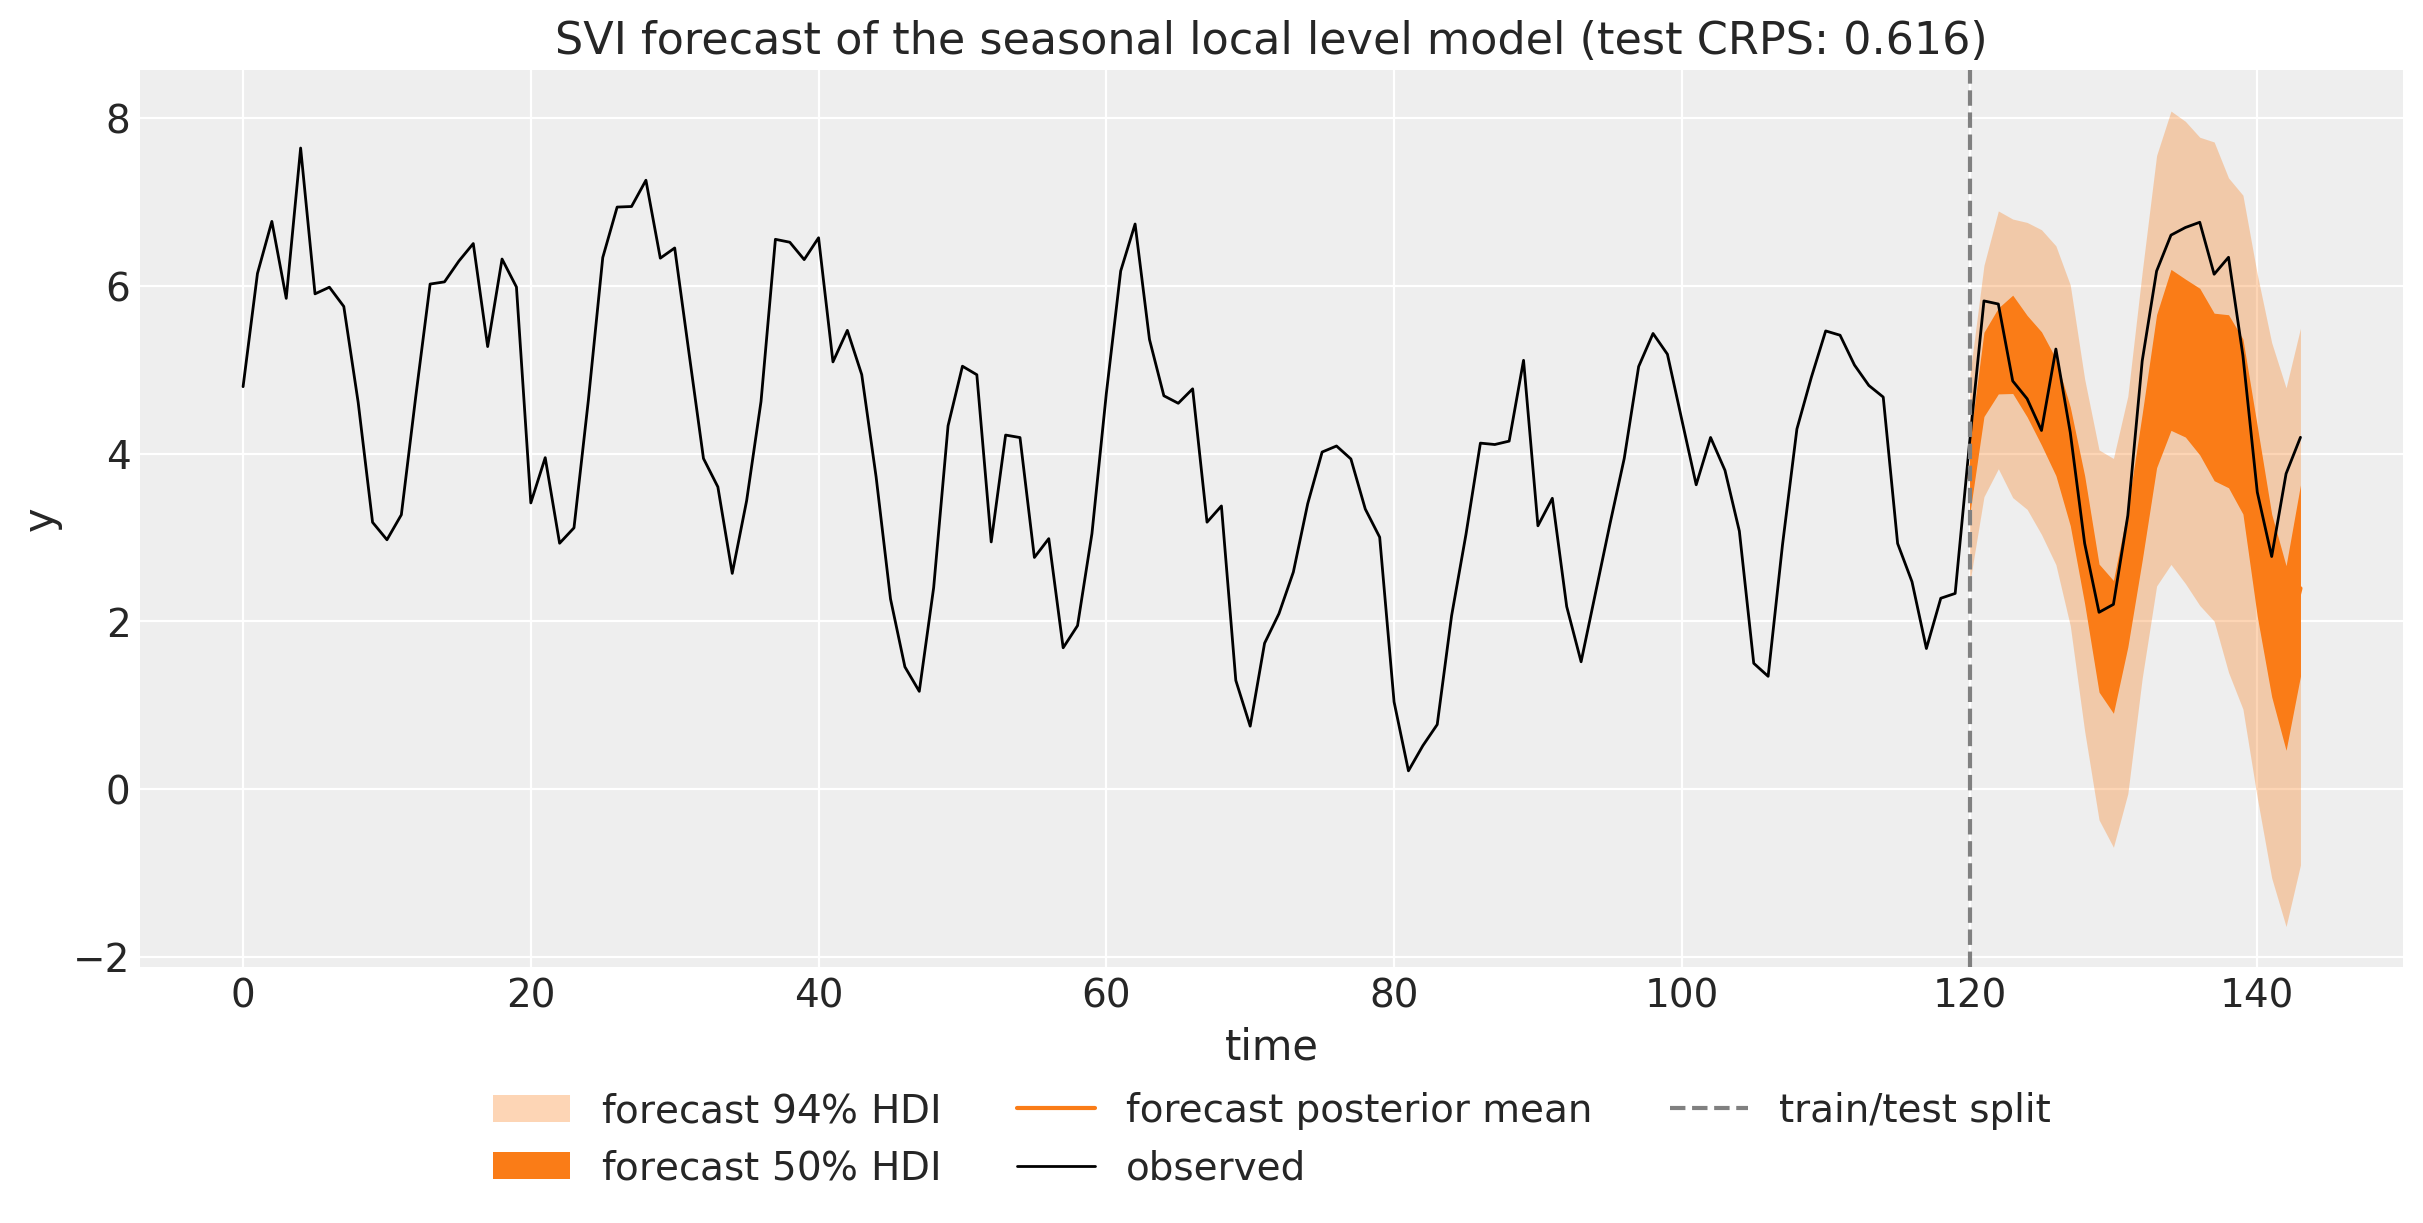

In [17]:
idata_forecast = predictions_to_datatree(
    forecast_svi, future_index.astype(float), ["y"], observed=test_seasonal
)
pc = az.plot_lm(
    idata_forecast,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
    },
    figure_kwargs={"figsize": (12, 6)},
)
bands = pc.viz["ci_band"]["t"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line = pc.viz["pe_line"]["t"].item()
pe_line.set_label("forecast posterior mean")
ax = pc.viz["figure"].item().axes[0]
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_line = ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
crps_svi = eval_crps(forecast_svi, test_seasonal)
ax.set(
    title=f"SVI forecast of the seasonal local level model (test CRPS: {crps_svi:.3f})",
    xlabel="time",
    ylabel="y",
);

### Expanding-window backtest

A single split scores one held-out window. [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html) moves the train/test boundary forward, refits from scratch and forecasts the next window, so every later part of the series is scored out of sample once. The loop delegates fitting and forecasting to a closure we write, `forecast_fn`, which here fits the marginalized model with NUTS on the fold's training window and hands the draws to `forecast`. The `dynestyx` model needs no adapter for this: it is a `numpyro_forecast` model, so the closure is the same one the other examples use. We size the folds at $12$ steps (`test_window=12`, `stride=12`) with the first $72$ observations seeding the initial training window, which gives six folds.

In [18]:
def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and forecast the test horizon."""
    key_fit, key_fc = random.split(rng_key)
    mcmc, _ = fit_nuts(
        key_fit,
        model,
        train_data,
        train_covariates,
        num_chains=2,
        num_warmup=500,
        num_samples=num_samples // 2,
    )
    return forecast(
        key_fc, model, mcmc.get_samples(), train_data, full_covariates, batch_size=batch_size
    )


backtest_metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
results = backtest(
    rng_subkey,
    y_seasonal,
    covariates_full,
    lambda: seasonal_level_filtered,
    forecast_fn=forecast_fn,
    metrics=backtest_metrics,
    test_window=12,
    stride=12,
    min_train_window=72,
    num_samples=1_000,  # 2 chains x 500 draws, what forecast_fn returns
    keep_predictions=True,
)
print(f"backtest: {len(results)} folds in {time.perf_counter() - start:.1f} s")
results_to_dataframe(results).round(3)

backtest: 6 folds in 37.9 s


,t0,t1,t2,num_samples,walltime,metric_crps,metric_coverage_50,metric_coverage_94
0,0,72,84,1000,5.774,0.653,0.333,0.917
1,0,84,96,1000,5.473,0.593,0.667,0.917
2,0,96,108,1000,6.026,0.460,0.667,1.000
3,0,108,120,1000,6.489,0.325,0.833,1.000
4,0,120,132,1000,6.651,0.353,0.833,1.000
5,0,132,144,1000,7.200,0.526,0.250,1.000


Overlaying every fold's out-of-sample forecast on the series gives the rolling-origin view: each band starts where its training window ends, with the dashed lines marking the successive splits.

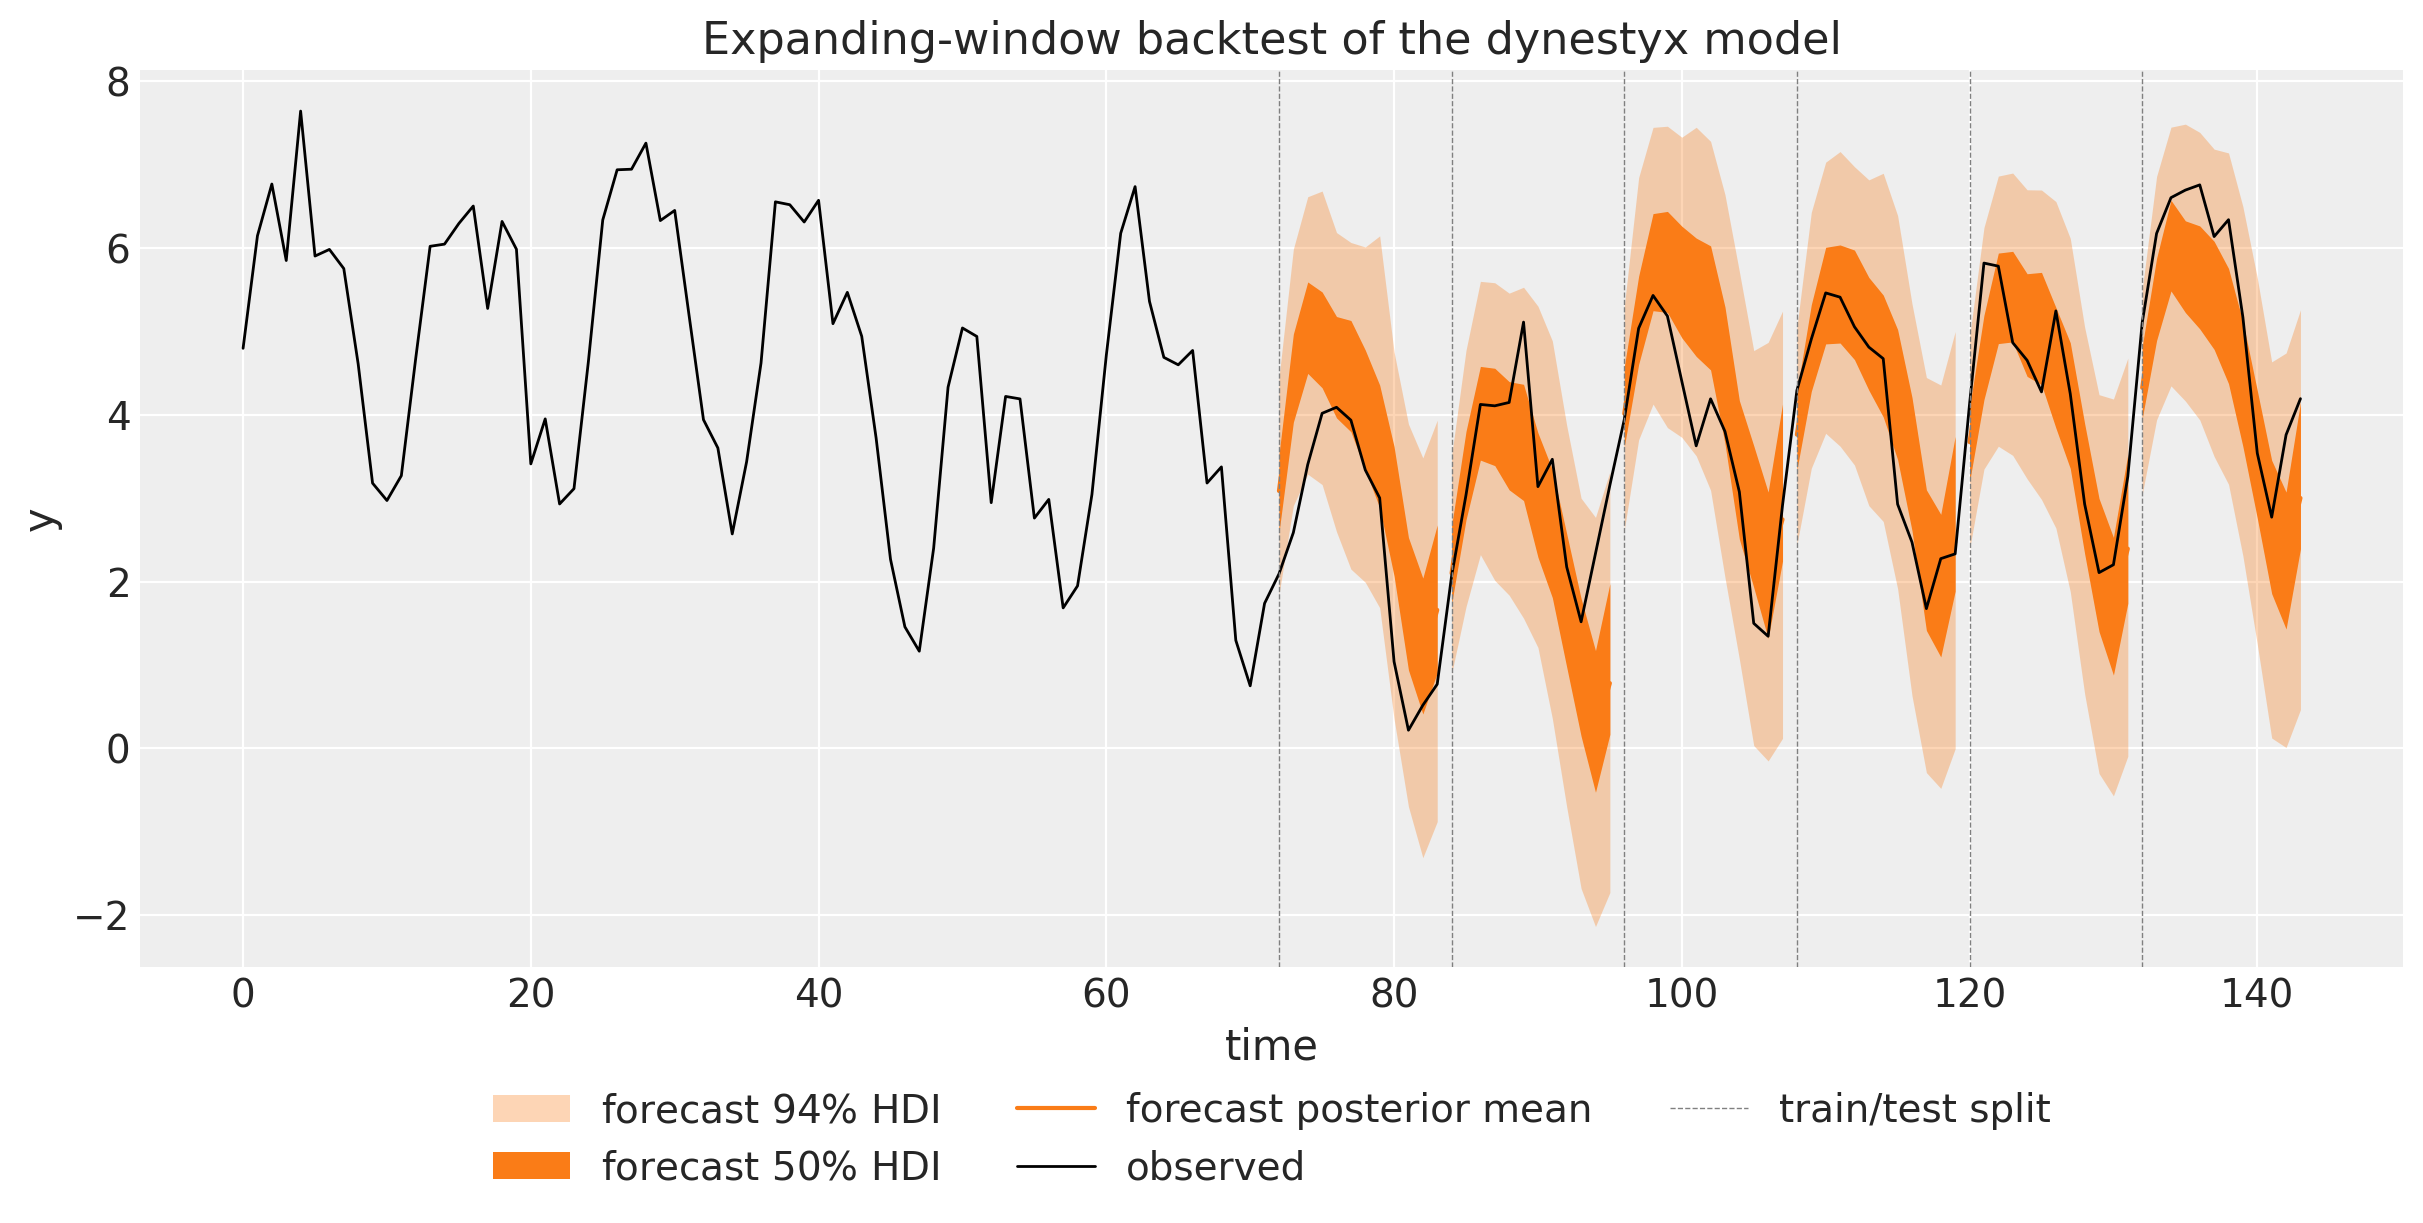

In [19]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    fold_time = time_index[r.t1 : r.t2].astype(float)
    idata_fold = predictions_to_datatree(
        prediction, fold_time, ["y"], observed=y_seasonal[r.t1 : r.t2]
    )
    if pc is None:
        pc = az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
            },
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["t"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
        pe_line = pc.viz["pe_line"]["t"].item()
    else:
        az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
            },
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line.set_label("forecast posterior mean")
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_lines[0]],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="Expanding-window backtest of the dynestyx model", xlabel="time", ylabel="y");

The per-fold scores summarize the picture: the CRPS stays in a narrow band across folds, and the empirical coverage of the central $50\%$ and $94\%$ intervals wobbles around the nominal levels, as expected with $12$ observations per fold (each observation moves the coverage by about $0.08$).

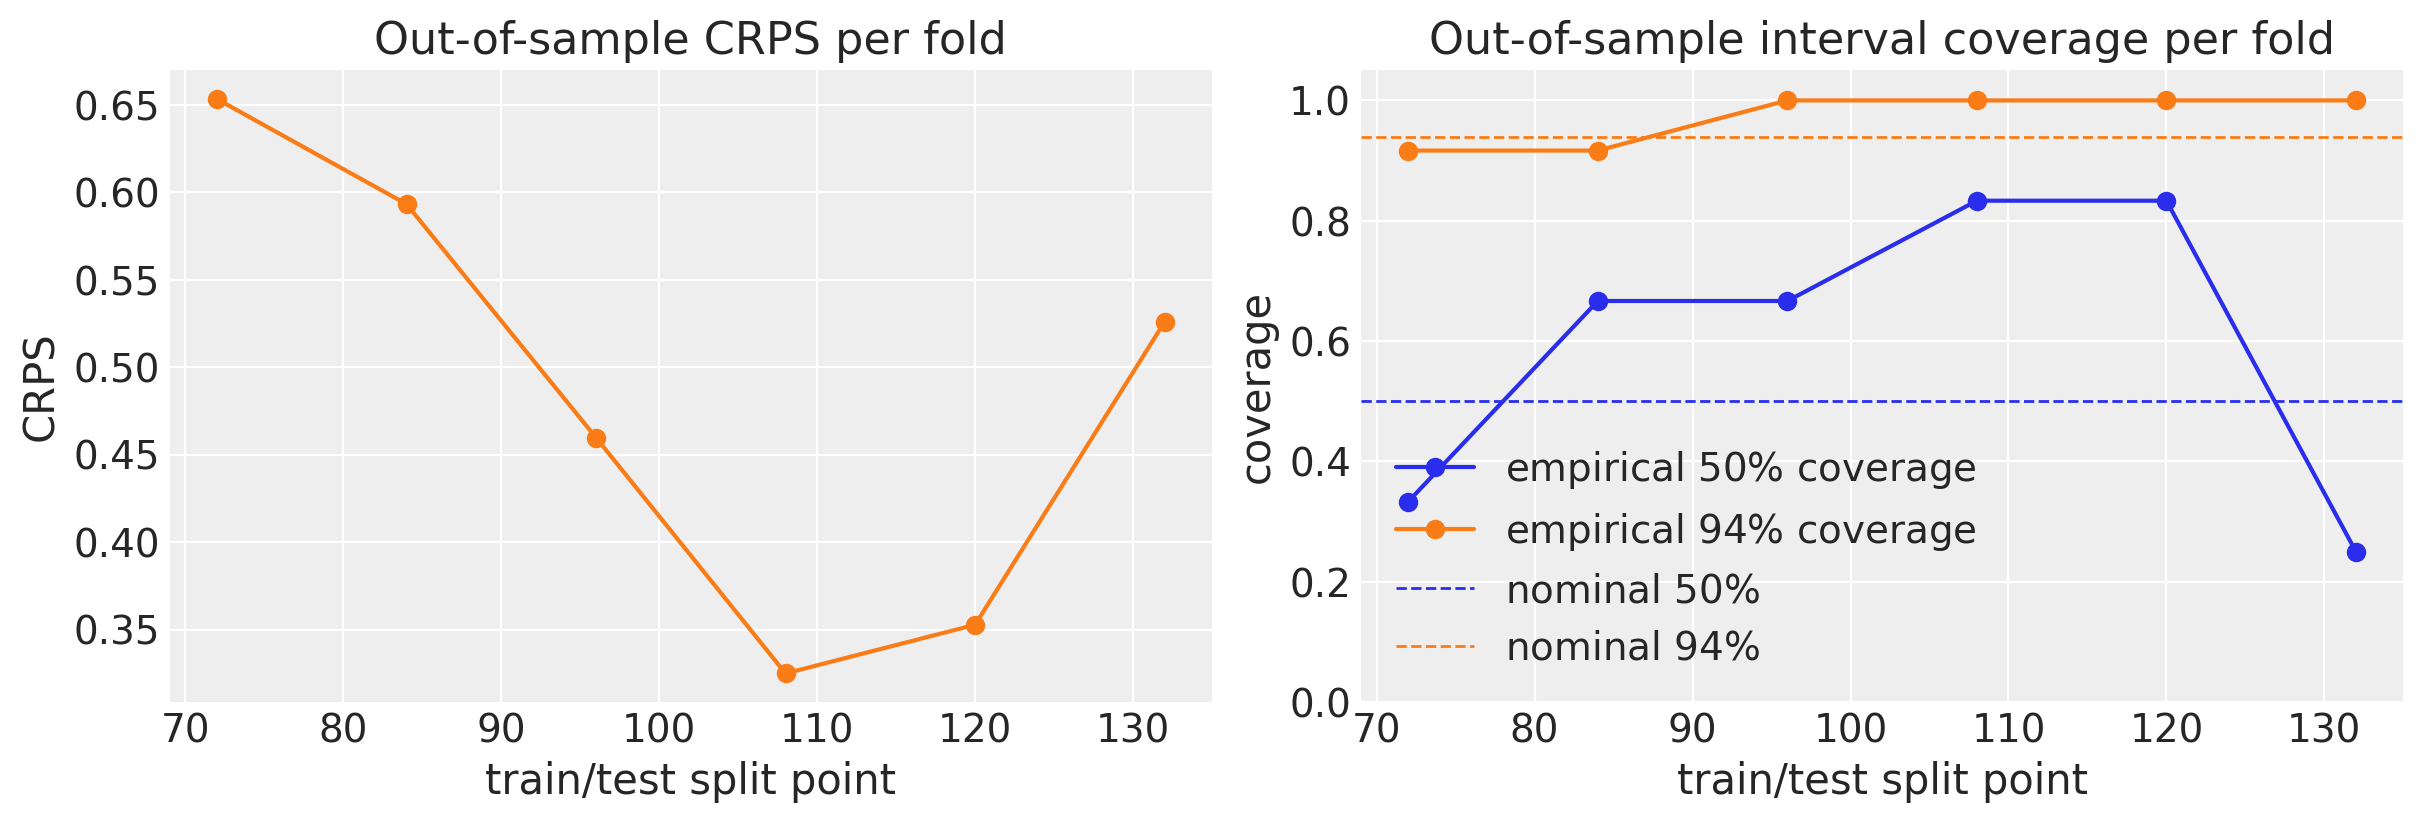

In [20]:
split_points = [r.t1 for r in results]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
axes[0].plot(split_points, [r.metrics["crps"] for r in results], "o-", color="C1")
axes[0].set(xlabel="train/test split point", ylabel="CRPS", title="Out-of-sample CRPS per fold")
axes[1].plot(
    split_points,
    [r.metrics["coverage_50"] for r in results],
    "o-",
    color="C0",
    label=r"empirical $50\%$ coverage",
)
axes[1].plot(
    split_points,
    [r.metrics["coverage_94"] for r in results],
    "o-",
    color="C1",
    label=r"empirical $94\%$ coverage",
)
axes[1].axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
axes[1].axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
axes[1].legend(loc="lower left")
axes[1].set(
    xlabel="train/test split point",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
    ylim=(0, 1.05),
);

## Takeaways

- A `dynestyx` model becomes a `numpyro_forecast` model through one building block. `filtered_series` conditions with a `Filter` while training and rolls out with a `Simulator` around the same `Filter` while forecasting; the model registers the result as `"forecast"`, and `forecast`, `backtest` and the metrics work on it unchanged, under the same `jit` and `vmap` as for every other model.
- The block owns two traps: the time grids must be host-side constants for the rollout to work under `jit`, and the rollout must be anchored at the last observed step, because the simulator's first predicted state is the filtered state there, without a transition.
- On linear-Gaussian models the filter is exact, so the marginalized fit is the direct fit with a better parameterization: the sampler explores the parameters only, and needs a small fraction of the gradient evaluations for a comparable or larger effective sample size. Beyond the linear-Gaussian case, `dynestyx`'s approximate filters (`EnKFConfig`, `UKFConfig`, `EKFConfig`, `PFConfig`) give pseudo-marginal inference for nonlinear and non-Gaussian dynamics that the package's direct blocks handle only by sampling every latent.
- Two package drivers do not apply to a marginalized model, `predict_in_sample` and `to_datatree`, because they call the model without data; the filtered states recorded by the filter are the in-sample view instead, and `dsx.simulate` is the prior predictive check. The `ssoe` family of the package (ARMA, exponential smoothing, Croston) is already marginalized by its deterministic recursion and gains nothing from a filter.

## References

- Waxman, D., Batenkov, D., Feser, J., Zane, A., Bingham, E., Marzouk, Y., & Levine, M. E. (2026). [*Dynestyx: A Probabilistic Programming Library for Dynamical Systems*](https://arxiv.org/abs/2606.16985).
- [`dynestyx` documentation](https://basisresearch.github.io/dynestyx/stable/), in particular the tutorial on filtering and the marginal likelihood.
- Durbin, J., & Koopman, S. J. (2012). *Time Series Analysis by State Space Methods*, 2nd edition. Oxford University Press.
- Särkkä, S., & Svensson, L. (2023). [*Bayesian Filtering and Smoothing*](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf), 2nd edition. Cambridge University Press.
- [`DYNESTYX_INTEGRATION_DESIGN.md`](https://github.com/juanitorduz/numpyro_forecast/blob/main/DYNESTYX_INTEGRATION_DESIGN.md), the design document behind this notebook.